In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from functools import reduce
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import scipy.stats as stats
from scipy.stats import jarque_bera, shapiro

import statsmodels.api as sm


C:\Users\DELL\AppData\Local\Temp\ipykernel_3192\506560858.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette="Set2")


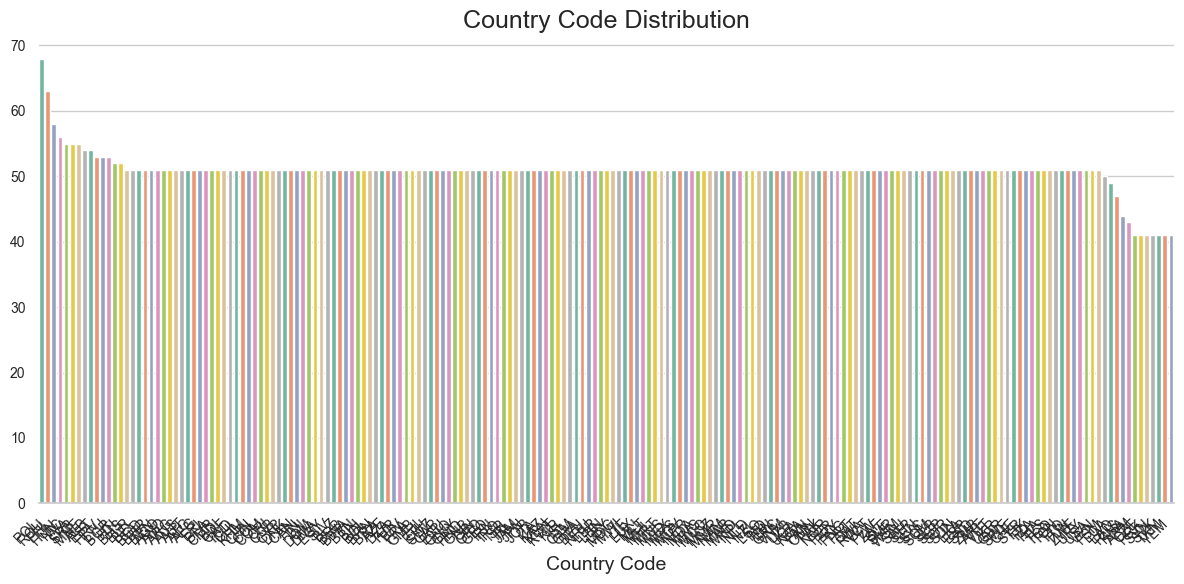

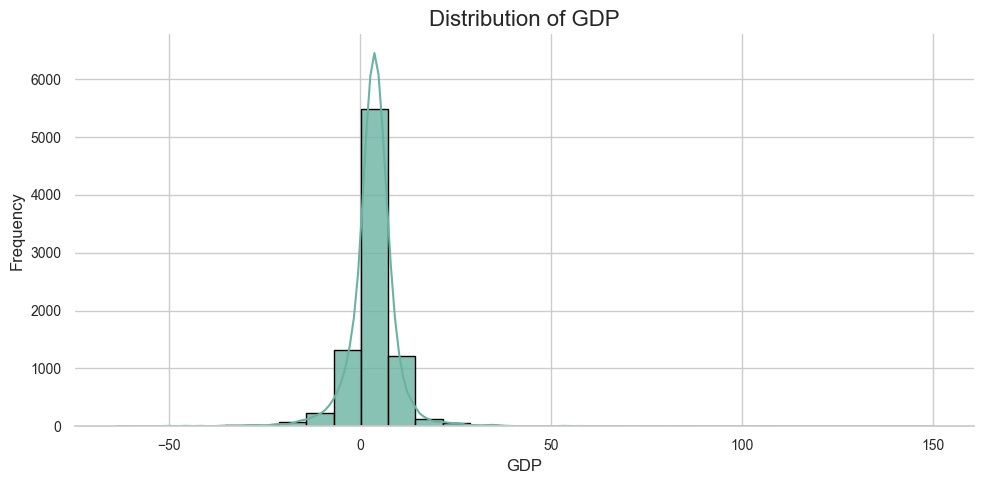

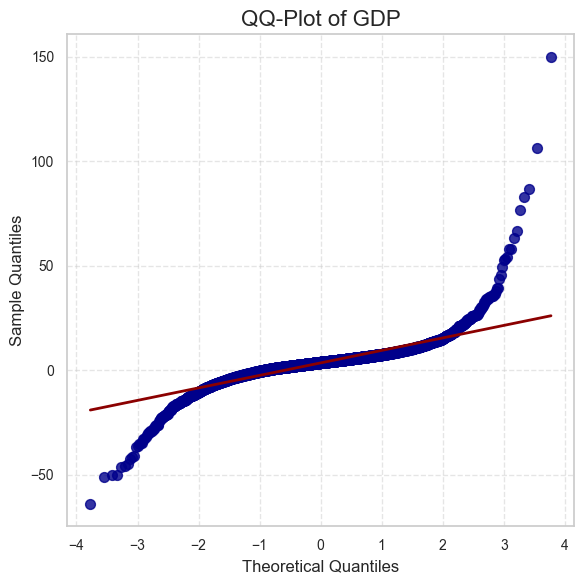

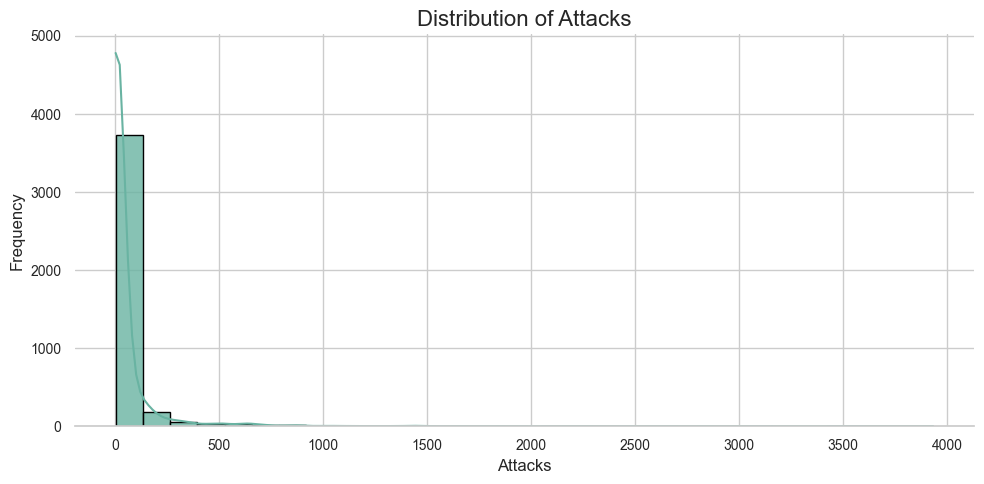

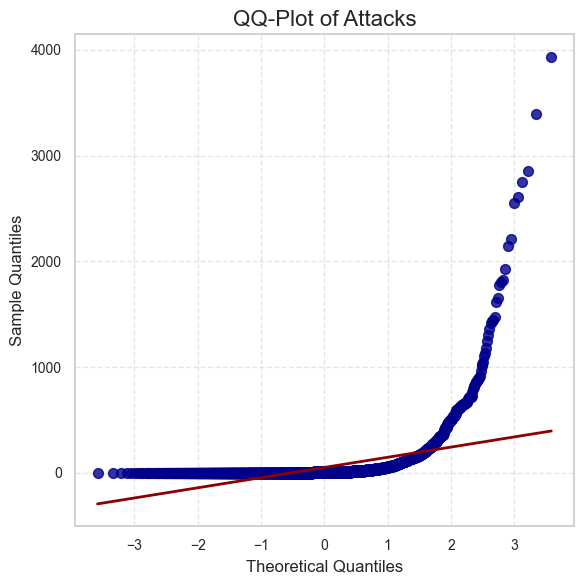

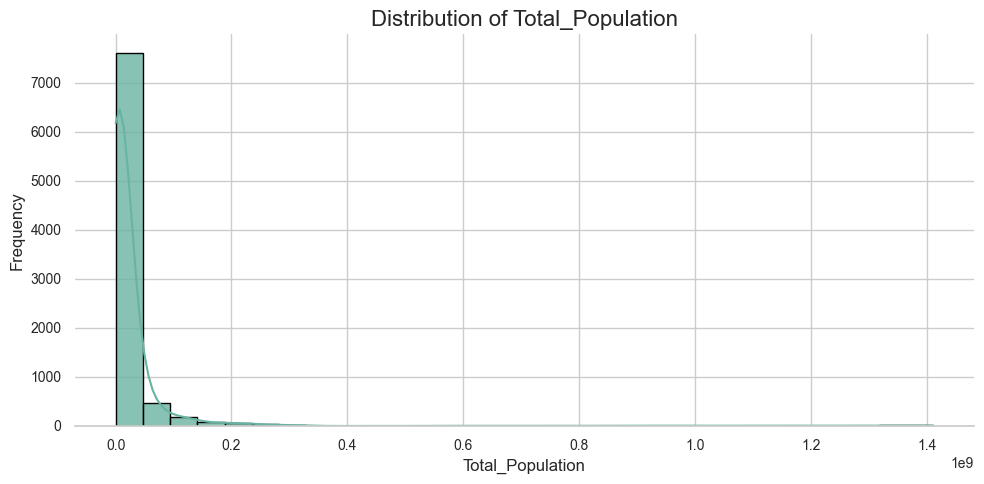

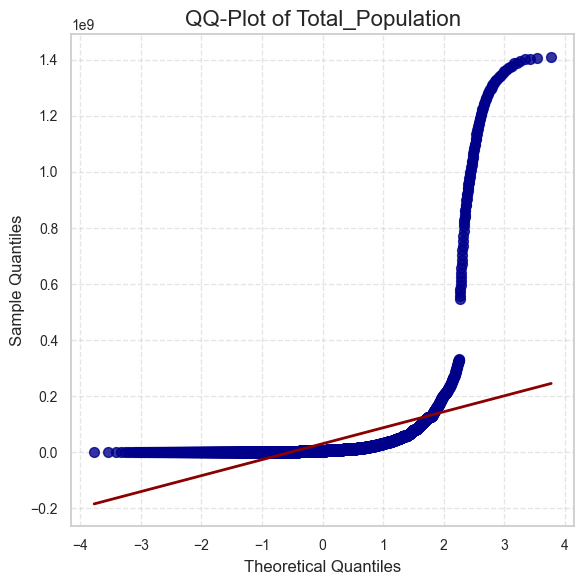

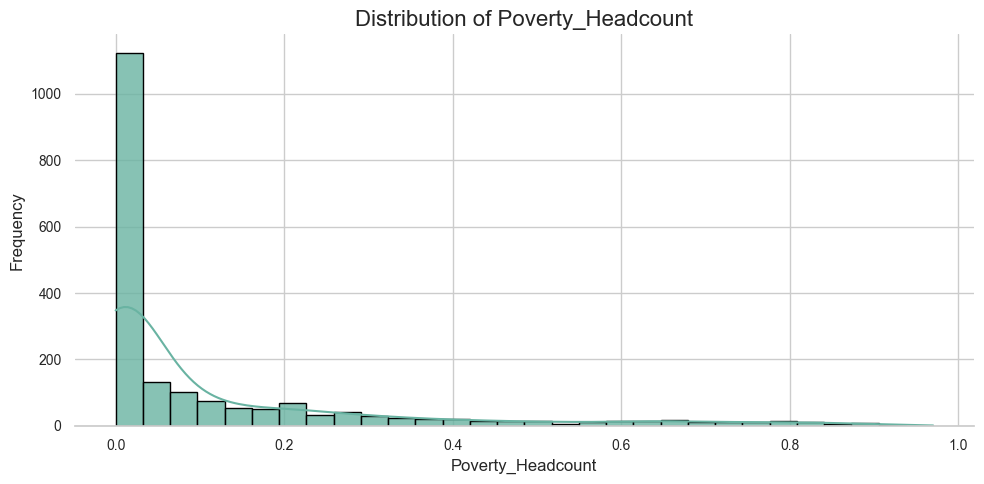

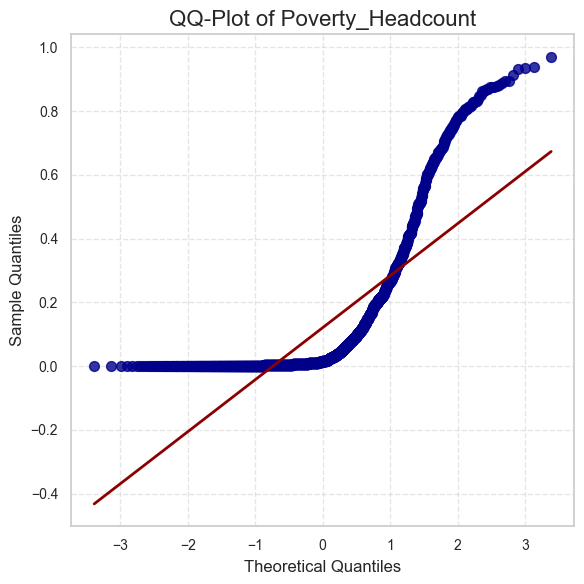

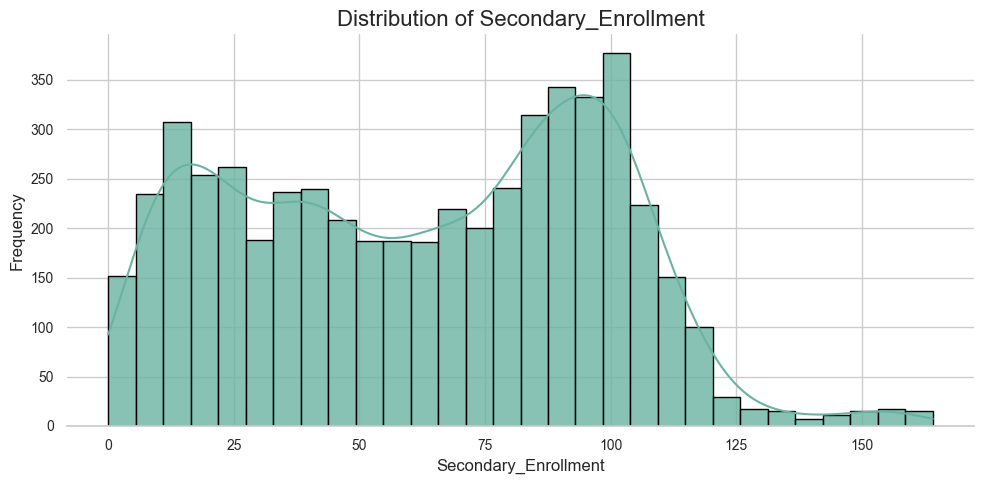

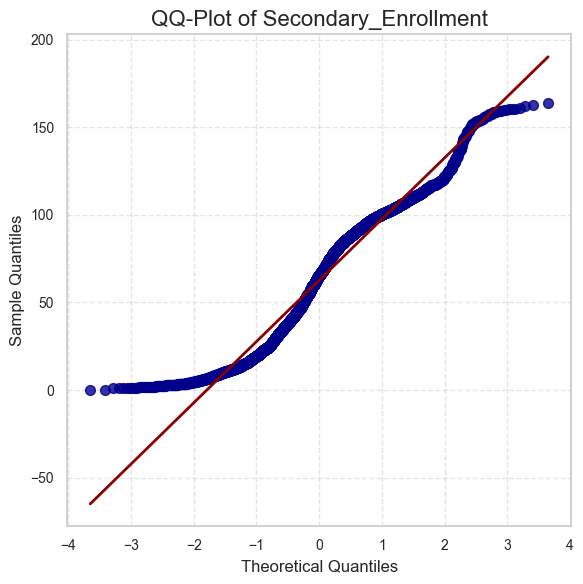

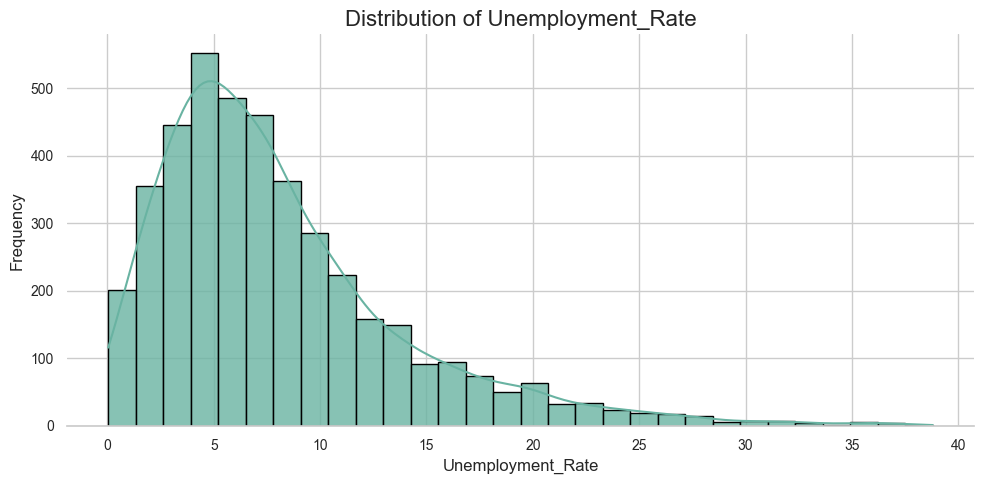

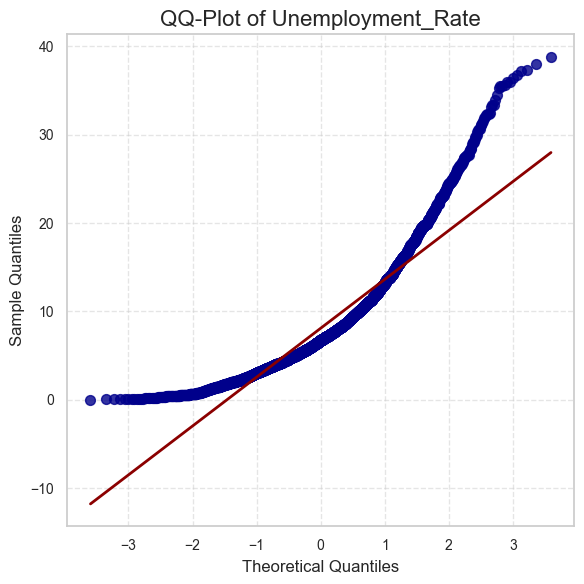

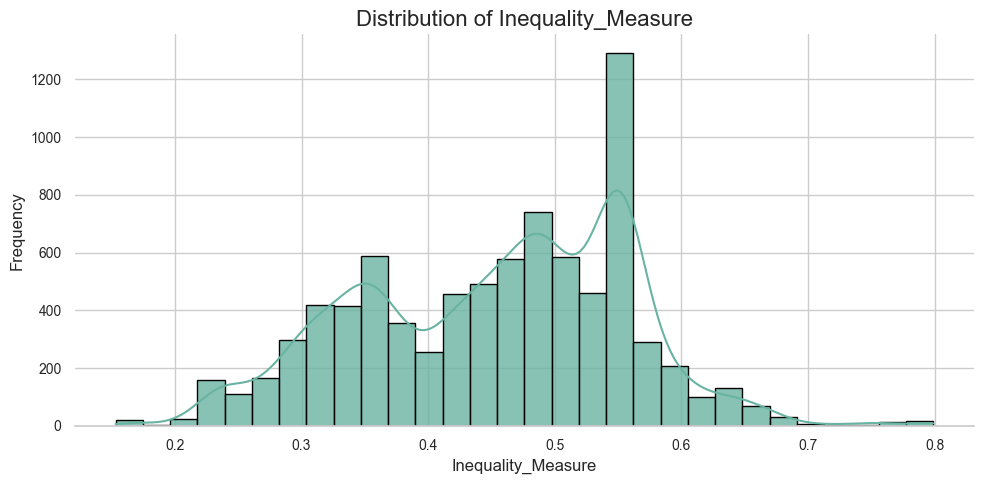

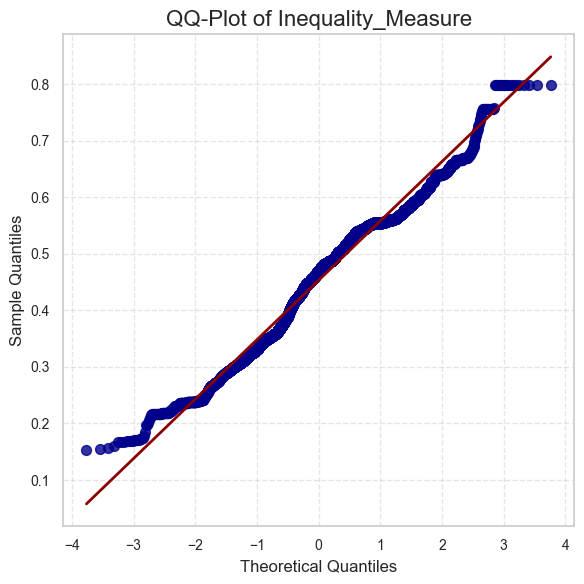

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Load data
df = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\Final_Master_Panel_AllColumns.xlsx")
df.columns = df.columns.str.strip()  # remove extra spaces

# Numeric columns
numeric_cols = ['GDP', 'Attacks', 'Total_Population', 'Poverty_Headcount',
                'Secondary_Enrollment', 'Unemployment_Rate', 'Inequality_Measure']

# Convert numeric columns to float
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Categorical columns to plot
categorical_cols = ['Country Code']

# Set Seaborn style for modern aesthetic
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams.update({'axes.titlesize': 16, 'axes.labelsize': 12, 'xtick.labelsize': 10, 'ytick.labelsize': 10})

# ---- CATEGORICAL PLOTS ----
for col in categorical_cols:
    plt.figure(figsize=(12, 6))
    ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette="Set2")
    
    # Optional: add soft outlines to bars
    for patch in ax.patches:
        patch.set_edgecolor('white')
    
    plt.title(f"{col} Distribution", fontsize=18)
    plt.xlabel(col, fontsize=14)
    plt.ylabel("")  # remove y-axis label for cleaner look
    plt.xticks(rotation=45, ha='right')
    sns.despine(left=True, bottom=False)
    plt.tight_layout()
    plt.show()

# ---- NUMERIC PLOTS + QQ PLOTS ----
for col in numeric_cols:
    if df[col].dropna().empty:
        continue  # skip empty columns

    # Histogram with KDE
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col].dropna(), kde=True, bins=30, color="#69b3a2", edgecolor='black', alpha=0.8)
    plt.title(f"Distribution of {col}", fontsize=16)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    sns.despine(left=True)
    plt.tight_layout()
    plt.show()
    
    # ---- QQ-plot with darker points and line ----
    plt.figure(figsize=(6, 6))
    res = stats.probplot(df[col].dropna(), dist="norm")

    # Scatter points
    plt.scatter(res[0][0], res[0][1], color='darkblue', s=50, alpha=0.8)

    # Fit line
    slope, intercept = res[1][0], res[1][1]
    plt.plot(res[0][0], slope*res[0][0] + intercept, color='darkred', lw=2)

    plt.title(f"QQ-Plot of {col}", fontsize=16)
    plt.xlabel("Theoretical Quantiles", fontsize=12)
    plt.ylabel("Sample Quantiles", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


📊 Distribution & QQ-Plot of GDP Growth (Combined Interpretation)

GDP growth rates are centered around zero, capturing periods of economic expansion and contraction

The distribution exhibits strong deviations from normality, with pronounced heavy tails

Extreme negative and positive values indicate economic crises and exceptional growth episodes

QQ-plot shows systematic departures from the normal reference line, especially in both tails

Non-normality appears structural rather than due to sampling variability

Normality assumption for GDP growth does not hold empirically


Distribution of Attacks – Insights

Histogram + Density Plot

Highly right-skewed: Most countries experience few attacks, while a few countries have extremely high numbers.

Long tail indicates presence of extreme outliers.

Majority of data concentrated near the lower end (0–100 attacks).

QQ-Plot

Strong deviation from normality, especially in the upper quantiles.

Upper tail of the distribution rises sharply → confirms heavy-tailed nature.

Indicates that parametric methods assuming normality may not be appropriate without transformation.

Implications for Analysis

Consider log or square-root transformation before parametric modeling.

Outliers may need special attention or robust statistical methods.

Skewness suggests count-based or non-parametric models (e.g., Poisson, negative binomial) could be more suitable.

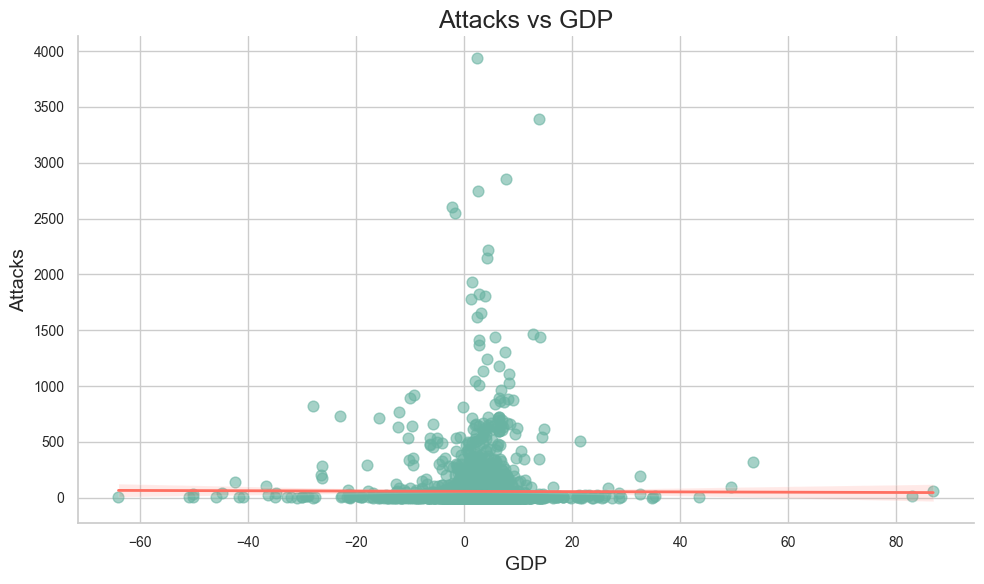

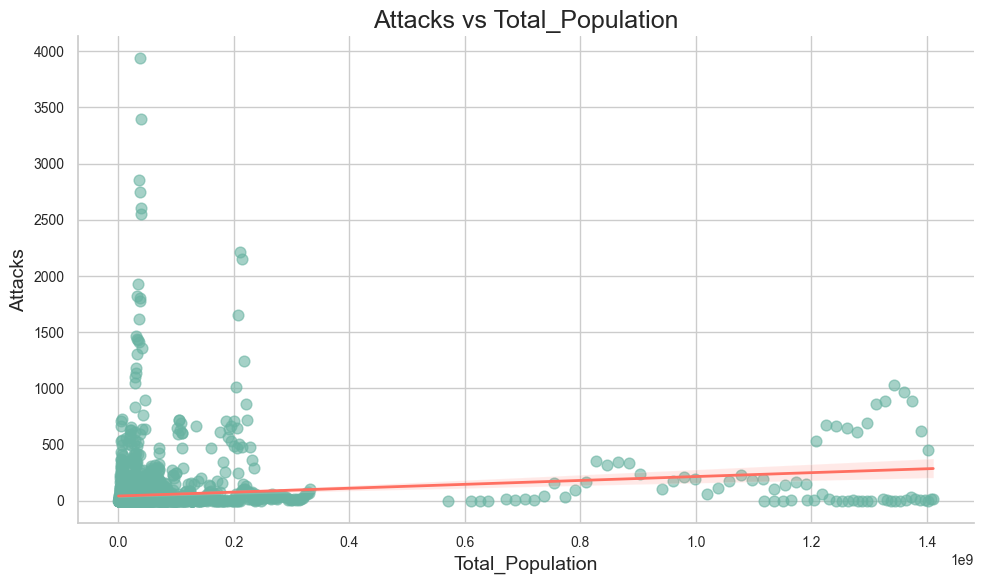

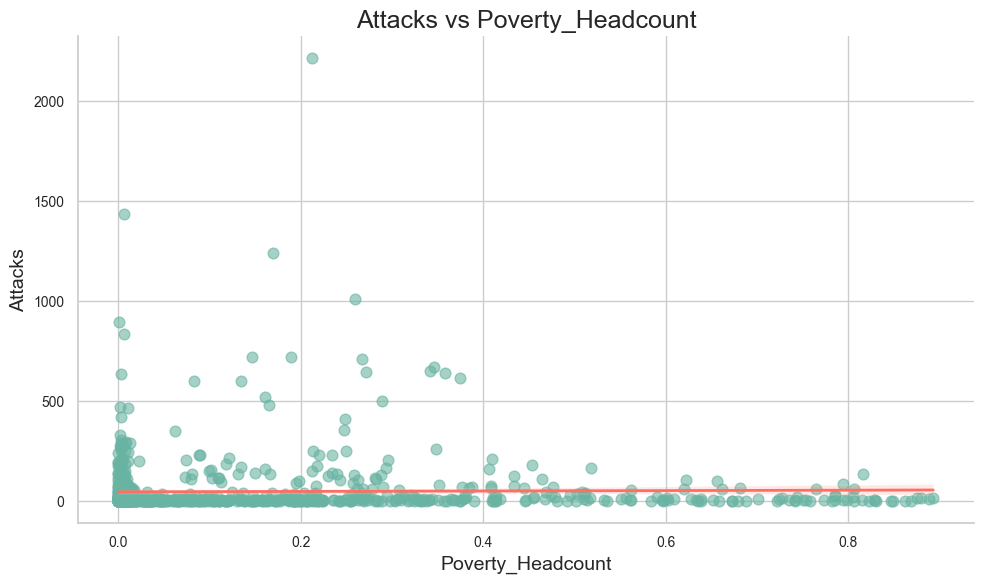

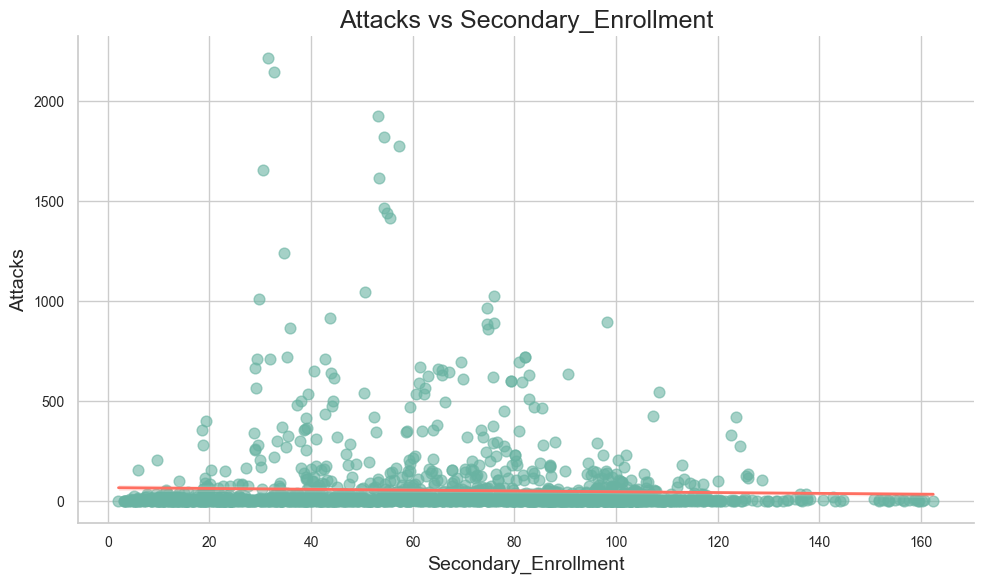

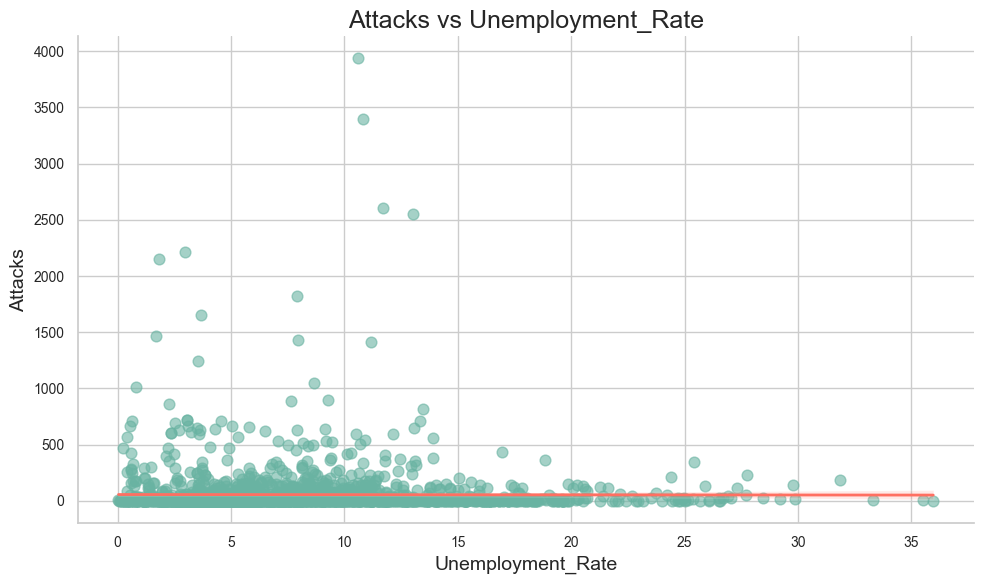

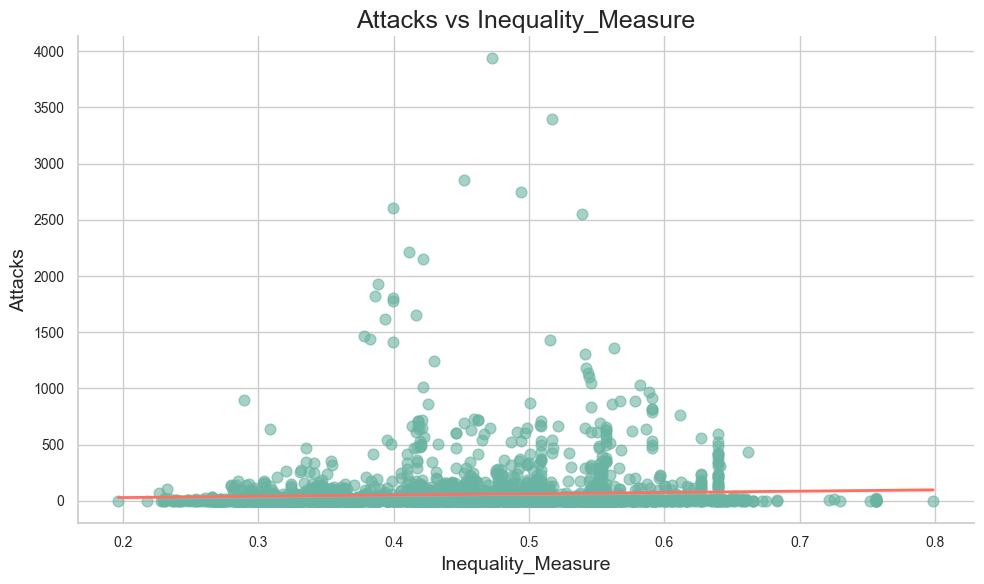

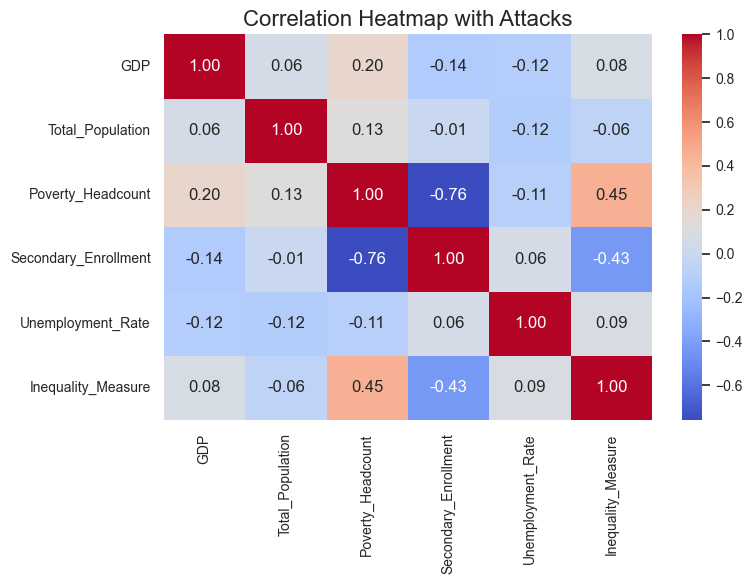

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\Final_Master_Panel_AllColumns.xlsx")
df.columns = df.columns.str.strip()  # remove extra spaces

# Numeric columns
numeric_cols = ['GDP', 'Total_Population', 'Poverty_Headcount',
                'Secondary_Enrollment', 'Unemployment_Rate', 'Inequality_Measure']

# Convert numeric columns to float
for col in numeric_cols + ['Attacks']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Set aesthetic style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'axes.titlesize': 16, 'axes.labelsize': 12, 'xtick.labelsize': 10, 'ytick.labelsize': 10})

# ---- Scatterplots with regression line ----
for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    sns.regplot(
        x=col, 
        y='Attacks', 
        data=df, 
        scatter_kws={'alpha':0.6, 's':60, 'color':'#69b3a2'}, 
        line_kws={'color':'#ff6f61', 'lw':2}
    )
    plt.title(f"Attacks vs {col}", fontsize=18)
    plt.xlabel(col, fontsize=14)
    plt.ylabel("Attacks", fontsize=14)
    sns.despine()
    plt.tight_layout()
    plt.show()

# ---- Optional: Correlation Heatmap ----
plt.figure(figsize=(8,6))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap with Attacks", fontsize=16)
plt.tight_layout()
plt.show()


Attacks vs Total Population

Terrorist attacks show high dispersion across population sizes, with no proportional increase as population grows.

Highly populated countries exhibit both very low and moderate attack counts, indicating population size alone is insufficient.

Extreme attack counts are driven by a small number of country–years, not by population magnitude.

The weak positive trend reflects exposure effects, not a causal relationship.

Conclusion:

Population is a scaling factor, not a substantive driver of terrorism.

2️⃣ Attacks vs Poverty Headcount

High attack counts occur at low to moderate poverty levels, contradicting a simple poverty–terrorism narrative.

Countries with very high poverty often show low recorded attack counts, possibly due to underreporting or different conflict dynamics.

Considerable variance at similar poverty levels suggests contextual and political factors dominate.

The relationship is non-linear and weak, with no monotonic trend.

Conclusion:

Poverty alone does not systematically explain terrorism intensity.

3️⃣ Attacks vs Secondary Enrollment

Terrorism occurs across all education levels, including countries with high enrollment rates.

No consistent protective or aggravating effect of secondary education is visible at the macro level.

High-attack observations appear sporadically, indicating education does not linearly reduce conflict risk.

The flat trend reflects structural heterogeneity across countries.

Conclusion:

Education indicators are insufficient as standalone predictors of terrorism.

4️⃣ Attacks vs Unemployment Rate

Terrorist attacks are concentrated at low-to-moderate unemployment rates, not at extremes.

Countries with very high unemployment often record low attack frequencies.

The absence of a clear upward trend challenges economic grievance-only explanations.

Outliers dominate visual interpretation, emphasizing non-economic conflict drivers.

Conclusion:

Unemployment is weakly associated and non-deterministic.

5️⃣ Attacks vs Inequality Measure

Higher inequality is associated with greater dispersion in attack counts, but not higher central tendency.

Both low and high inequality countries experience terrorism, indicating conditional effects.

A few high-attack observations inflate perceived association.

No stable functional form exists between inequality and terrorism.

Conclusion:

Inequality may amplify risk in specific contexts but is not a universal driver.

6️⃣ Attacks vs GDP Growth Rate

Terrorist attacks are observed across both negative and positive GDP growth rates, indicating no consistent economic-cycle effect.

Years of strong economic growth still experience high attack counts, suggesting growth does not necessarily reduce terrorism.

Similarly, periods of economic contraction do not uniformly correspond to higher terrorism.

The flat and highly dispersed pattern reflects a weak and non-monotonic association.

Conclusion:

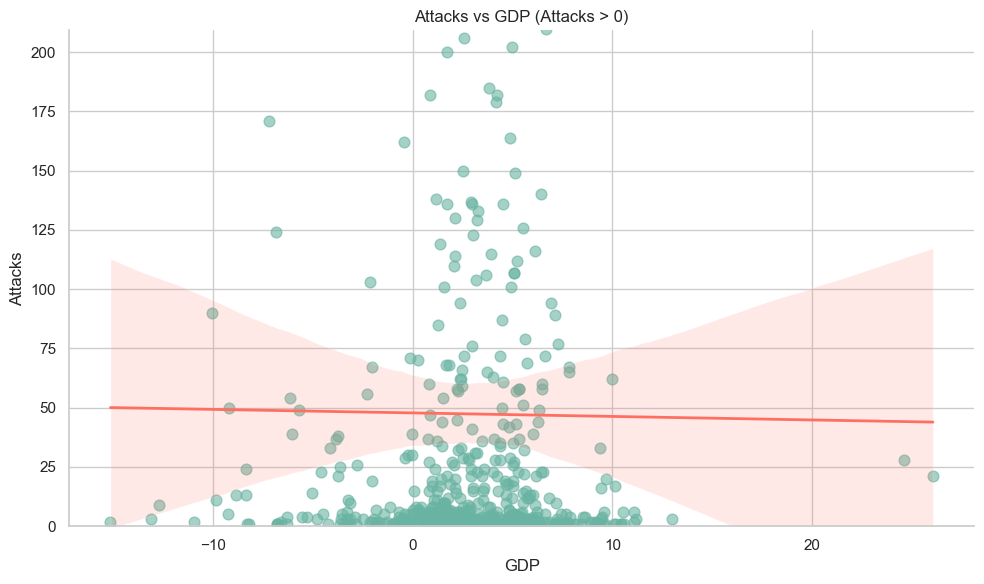

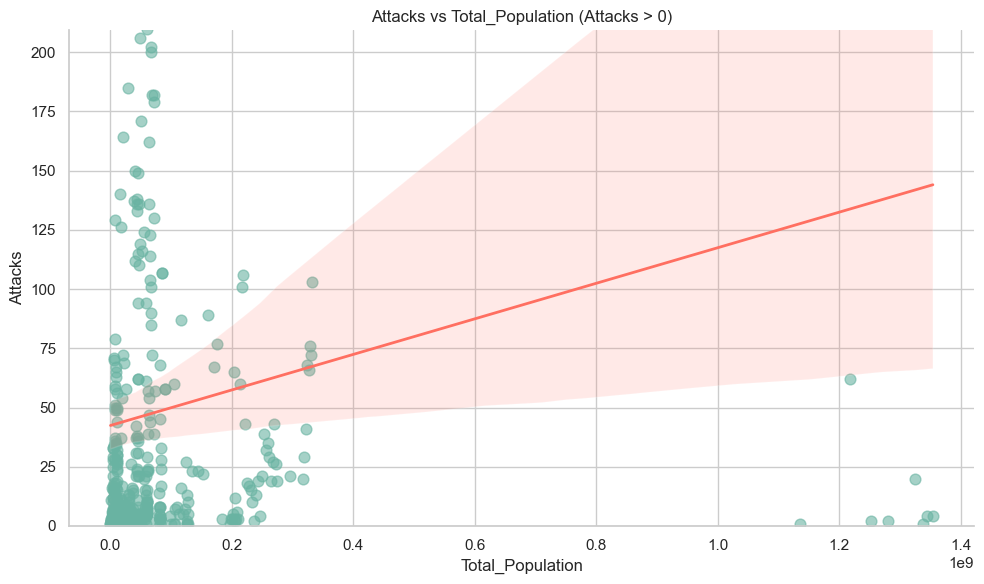

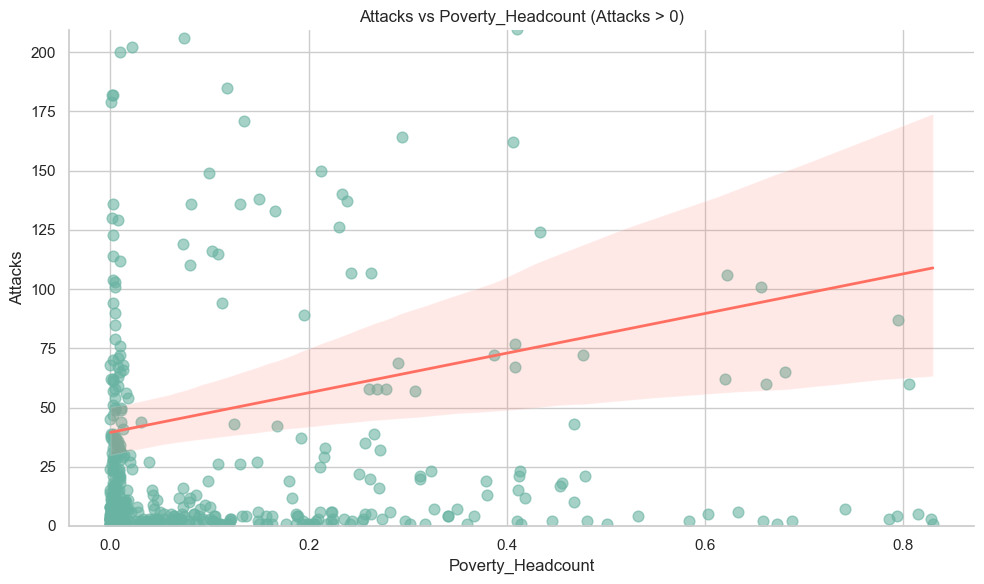

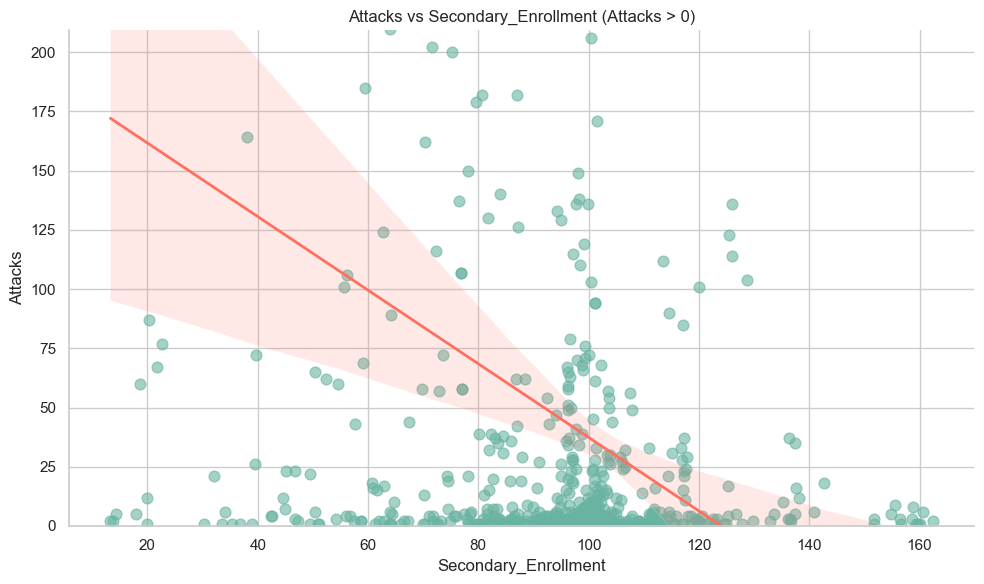

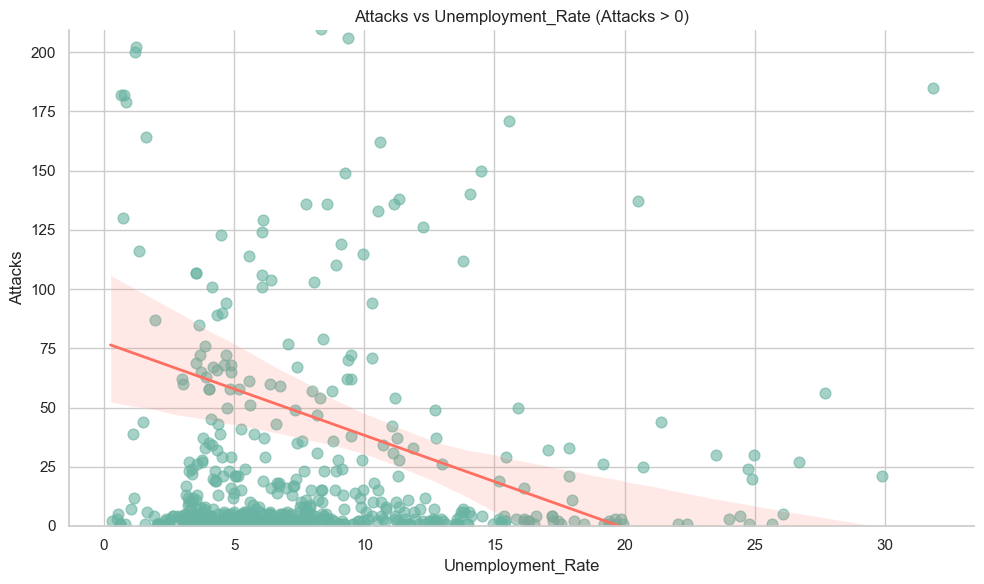

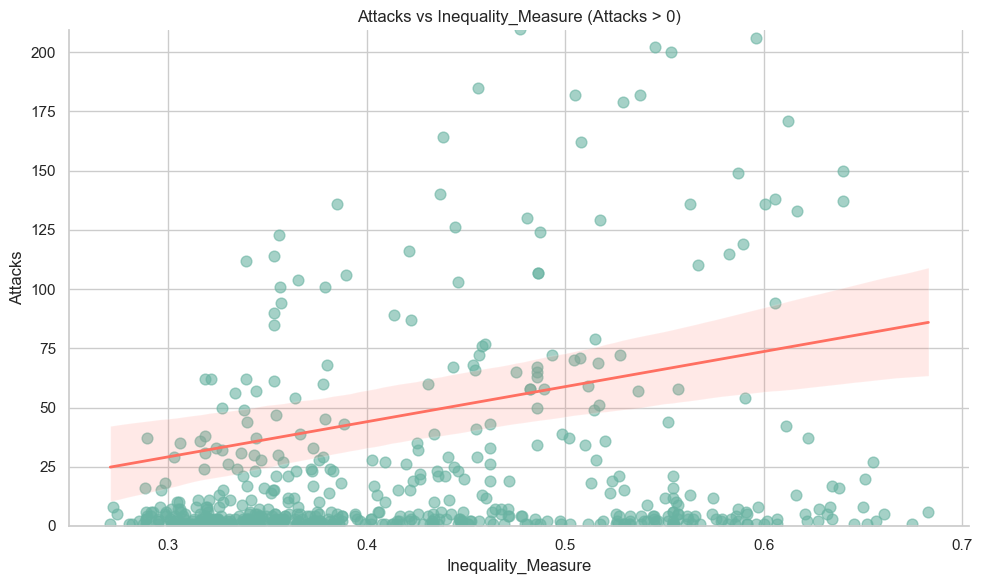

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_excel(
    r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\Final_Master_Panel_AllColumns.xlsx"
)
df.columns = df.columns.str.strip()

numeric_cols = [
    'GDP',
    'Total_Population',
    'Poverty_Headcount',
    'Secondary_Enrollment',
    'Unemployment_Rate',
    'Inequality_Measure'
]

for col in numeric_cols + ['Attacks']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Keep only Attacks > 0
df = df[df['Attacks'] > 0]
df = df.dropna(subset=numeric_cols + ['Attacks'])

# Y-axis upper bound (e.g. 95th percentile)
y_max = df['Attacks'].quantile(0.95)

sns.set_theme(style="whitegrid")

for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    sns.regplot(
        x=col,
        y='Attacks',
        data=df,
        scatter_kws={'alpha': 0.6, 's': 60, 'color': '#69b3a2'},
        line_kws={'color': '#ff6f61', 'lw': 2}
    )
    plt.ylim(0, y_max)   # 👈 KEY LINE
    plt.title(f"Attacks vs {col} (Attacks > 0)")
    plt.xlabel(col)
    plt.ylabel("Attacks")
    sns.despine()
    plt.tight_layout()
    plt.show()


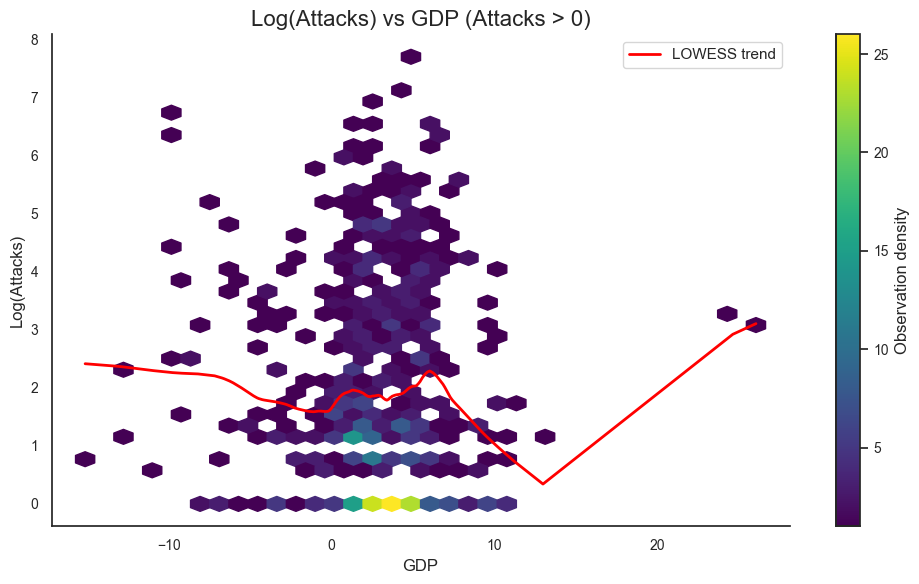

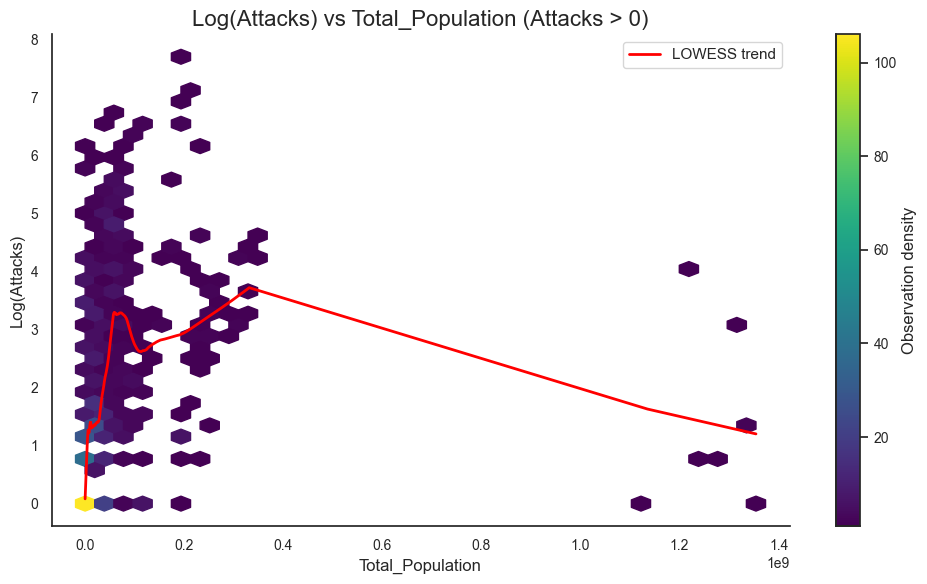

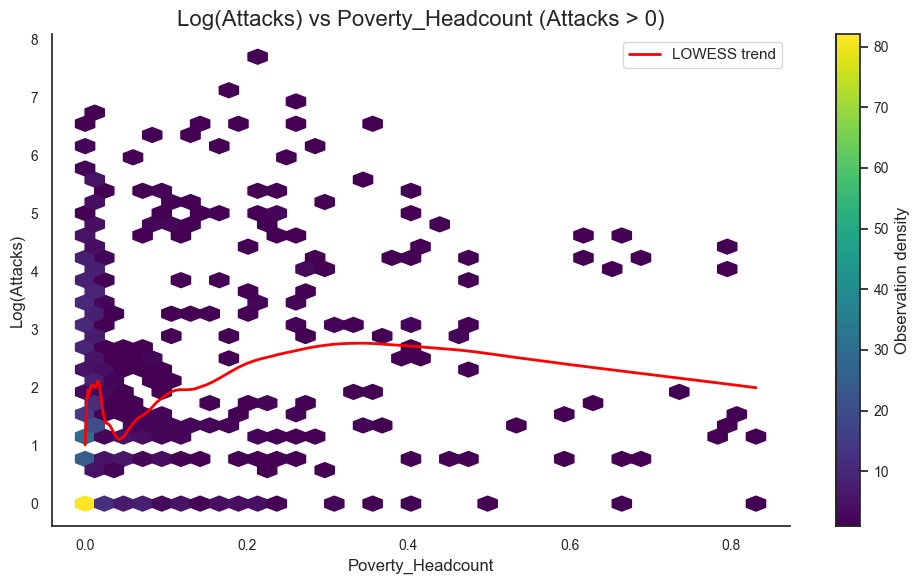

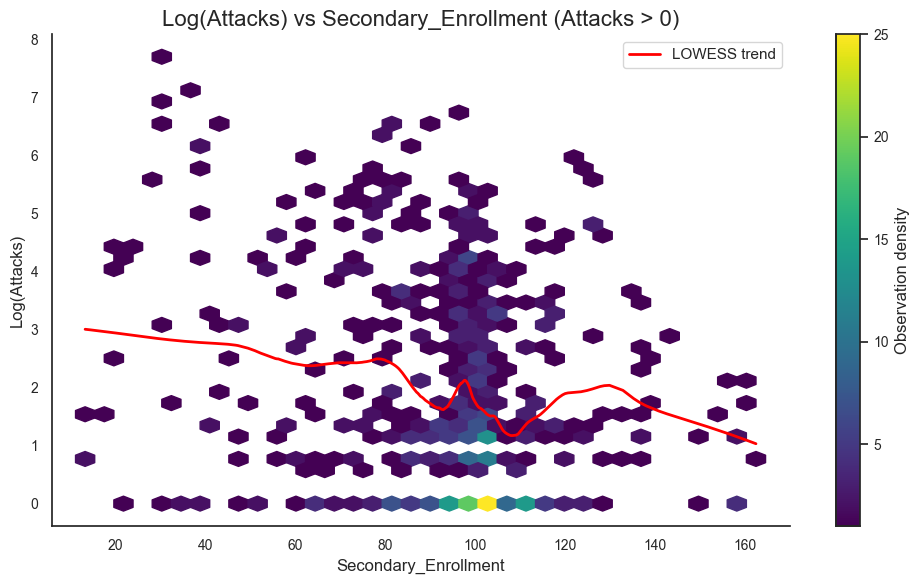

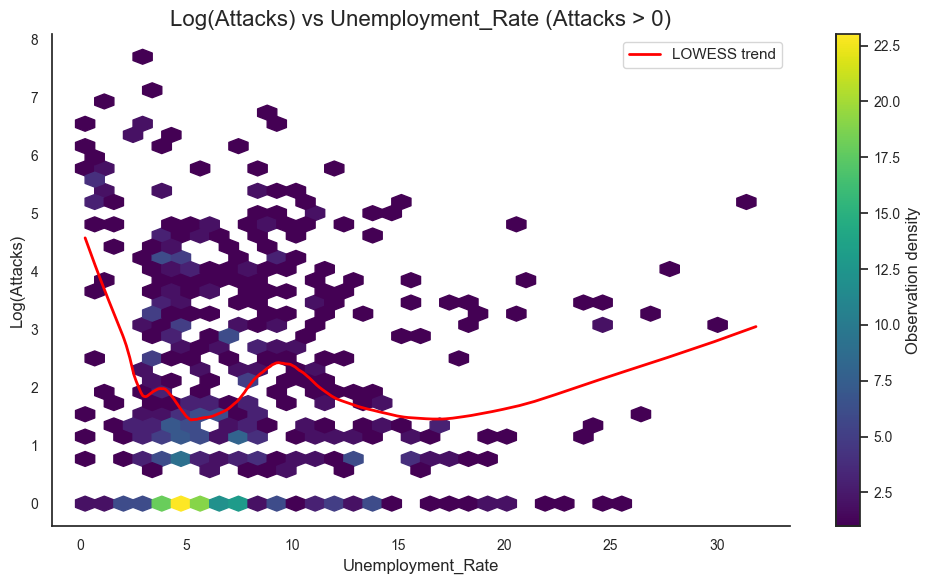

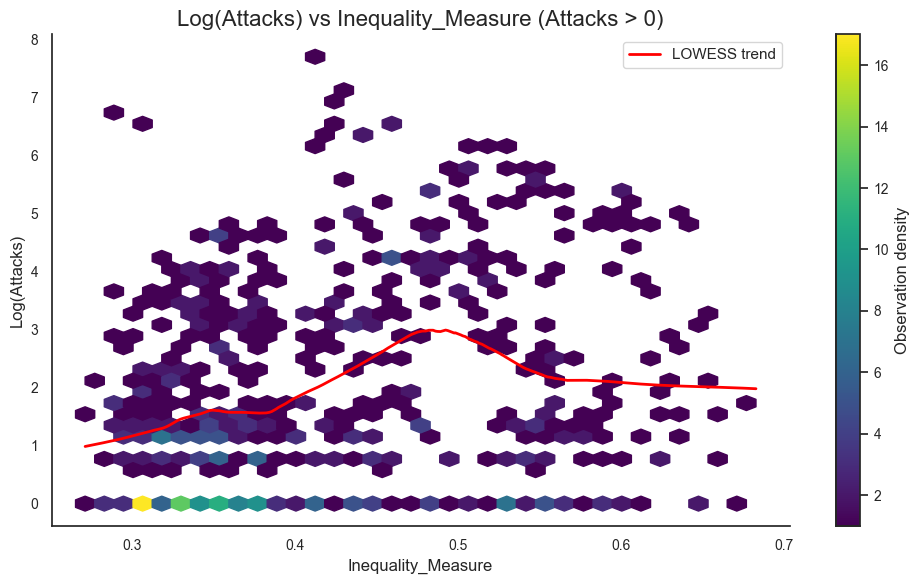

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

# --------------------------
# Load data
# --------------------------
df = pd.read_excel(
    r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\Final_Master_Panel_AllColumns.xlsx"
)
df.columns = df.columns.str.strip()

# --------------------------
# Variables (GDP Growth included)
# --------------------------
numeric_cols = [
    'GDP',
    'Total_Population',
    'Poverty_Headcount',
    'Secondary_Enrollment',
    'Unemployment_Rate',
    'Inequality_Measure'
]

# Convert to numeric
for col in numeric_cols + ['Attacks']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# --------------------------
# Remove zero-attack observations (VISUALIZATION ONLY)
# --------------------------
df = df[df['Attacks'] > 0]

# Drop remaining missing values
df = df.dropna(subset=numeric_cols + ['Attacks'])

# Log-transform attacks
df['log_Attacks'] = np.log(df['Attacks'])

# --------------------------
# Plot settings
# --------------------------
sns.set_theme(style="white")
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# --------------------------
# Hexbin + LOWESS plots
# --------------------------
for col in numeric_cols:
    plt.figure(figsize=(10, 6))

    hb = plt.hexbin(
        df[col],
        df['log_Attacks'],
        gridsize=35,
        cmap='viridis',
        mincnt=1
    )
    plt.colorbar(hb, label='Observation density')

    lowess_curve = lowess(
        df['log_Attacks'],
        df[col],
        frac=0.3
    )
    plt.plot(
        lowess_curve[:, 0],
        lowess_curve[:, 1],
        color='red',
        lw=2,
        label='LOWESS trend'
    )

    plt.title(f"Log(Attacks) vs {col} (Attacks > 0)")
    plt.xlabel(col)
    plt.ylabel("Log(Attacks)")
    plt.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()


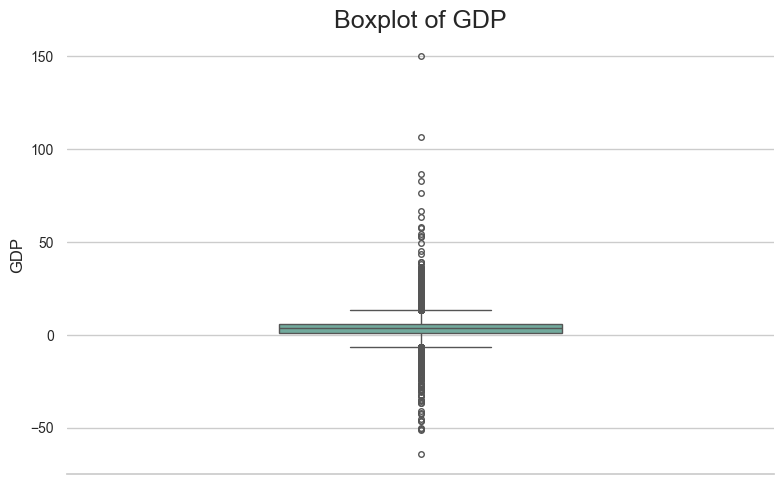

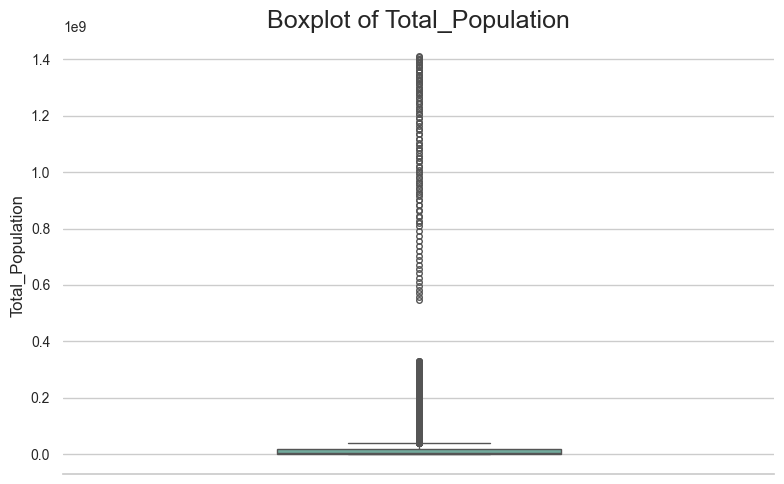

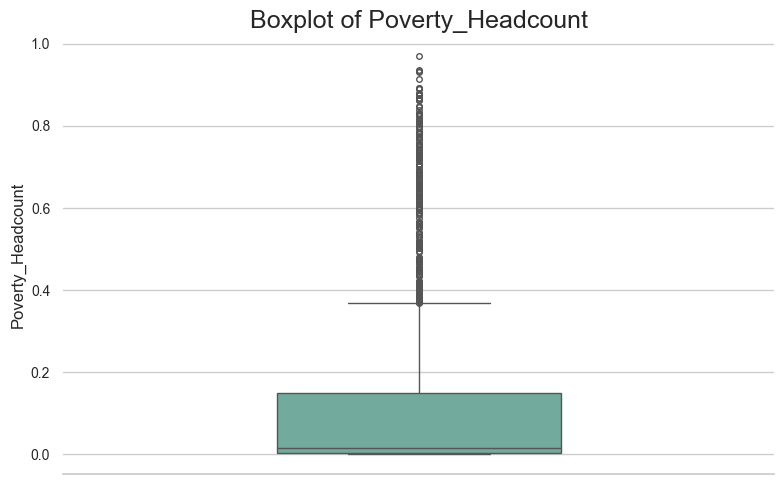

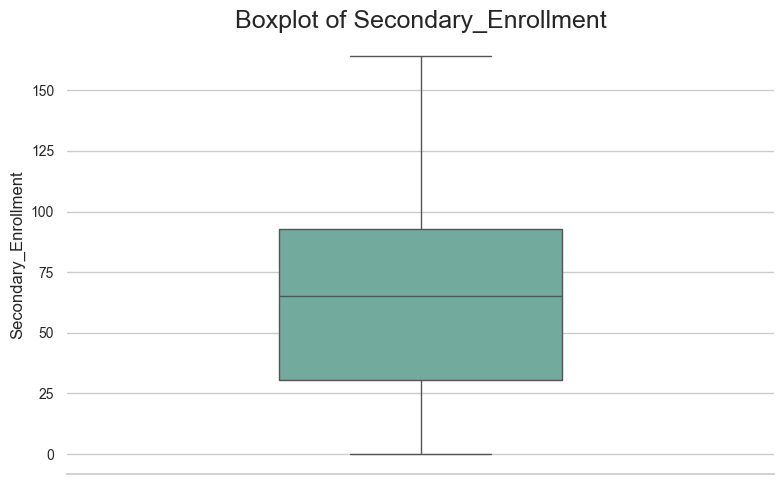

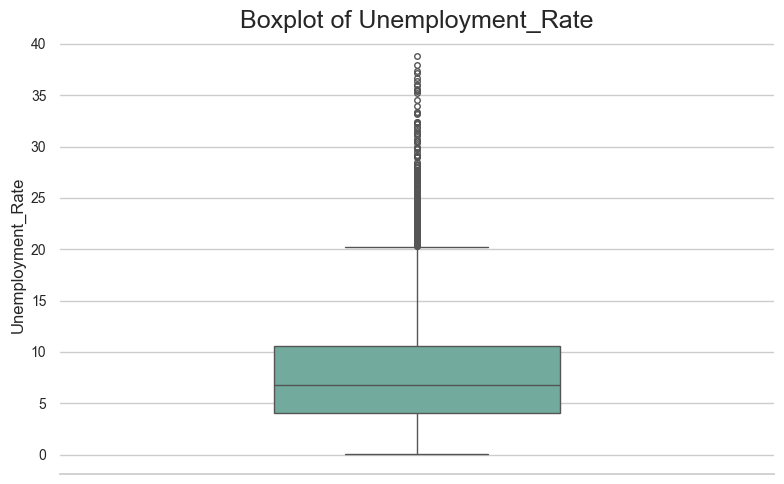

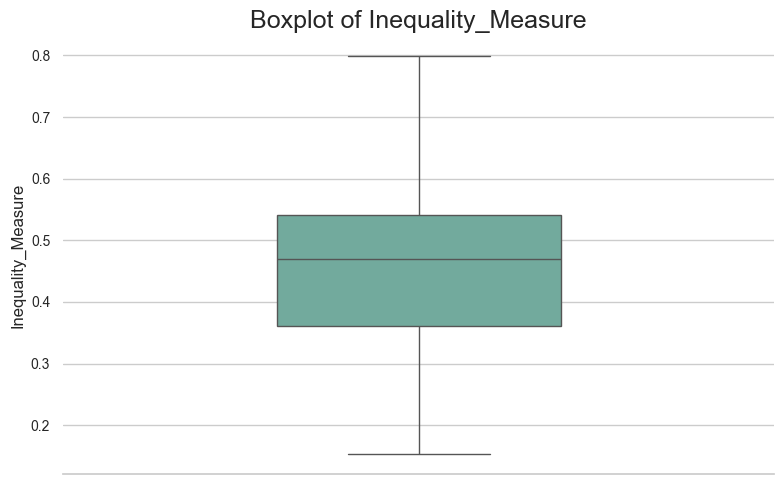

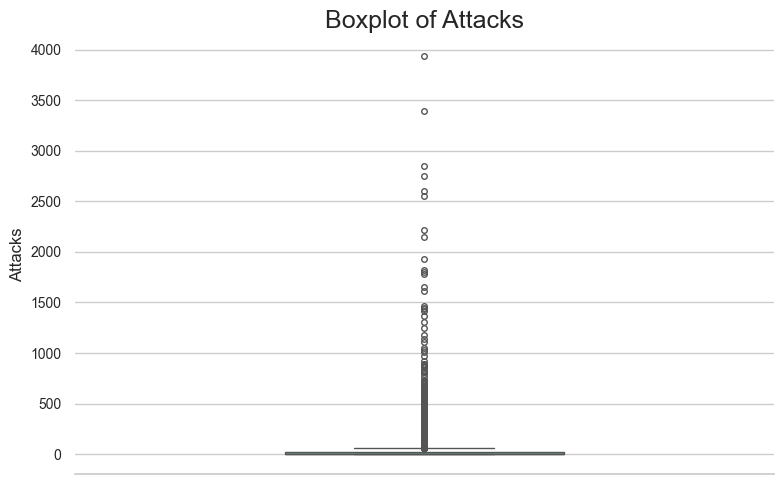

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\Final_Master_Panel_AllColumns.xlsx")
df.columns = df.columns.str.strip()

# Socio-economic indicators
numeric_cols = [
    'GDP',
    'Total_Population',
    'Poverty_Headcount',
    'Secondary_Enrollment',
    'Unemployment_Rate',
    'Inequality_Measure',
    'Attacks'
]

# Convert to numeric
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Aesthetic settings
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# ---- Boxplots ----
for col in numeric_cols:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        y=df[col],
        color="#69b3a2",
        width=0.4,
        fliersize=4
    )

    plt.title(f"Boxplot of {col}", fontsize=18)
    plt.ylabel(col)
    plt.xlabel("")
    sns.despine(left=True)
    plt.tight_layout()
    plt.show()


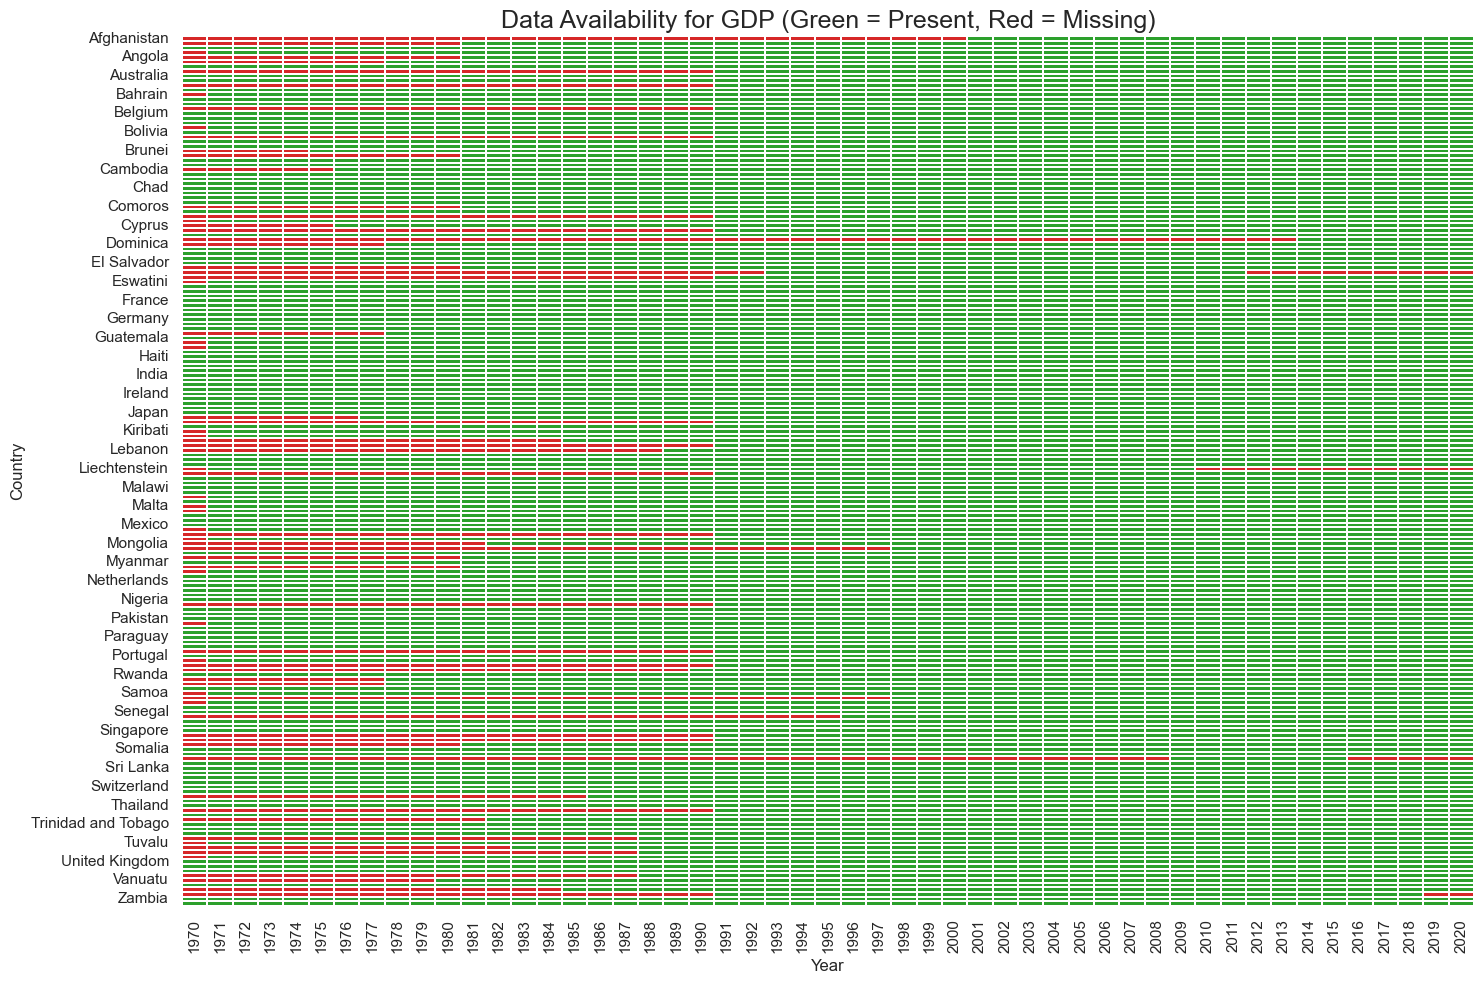

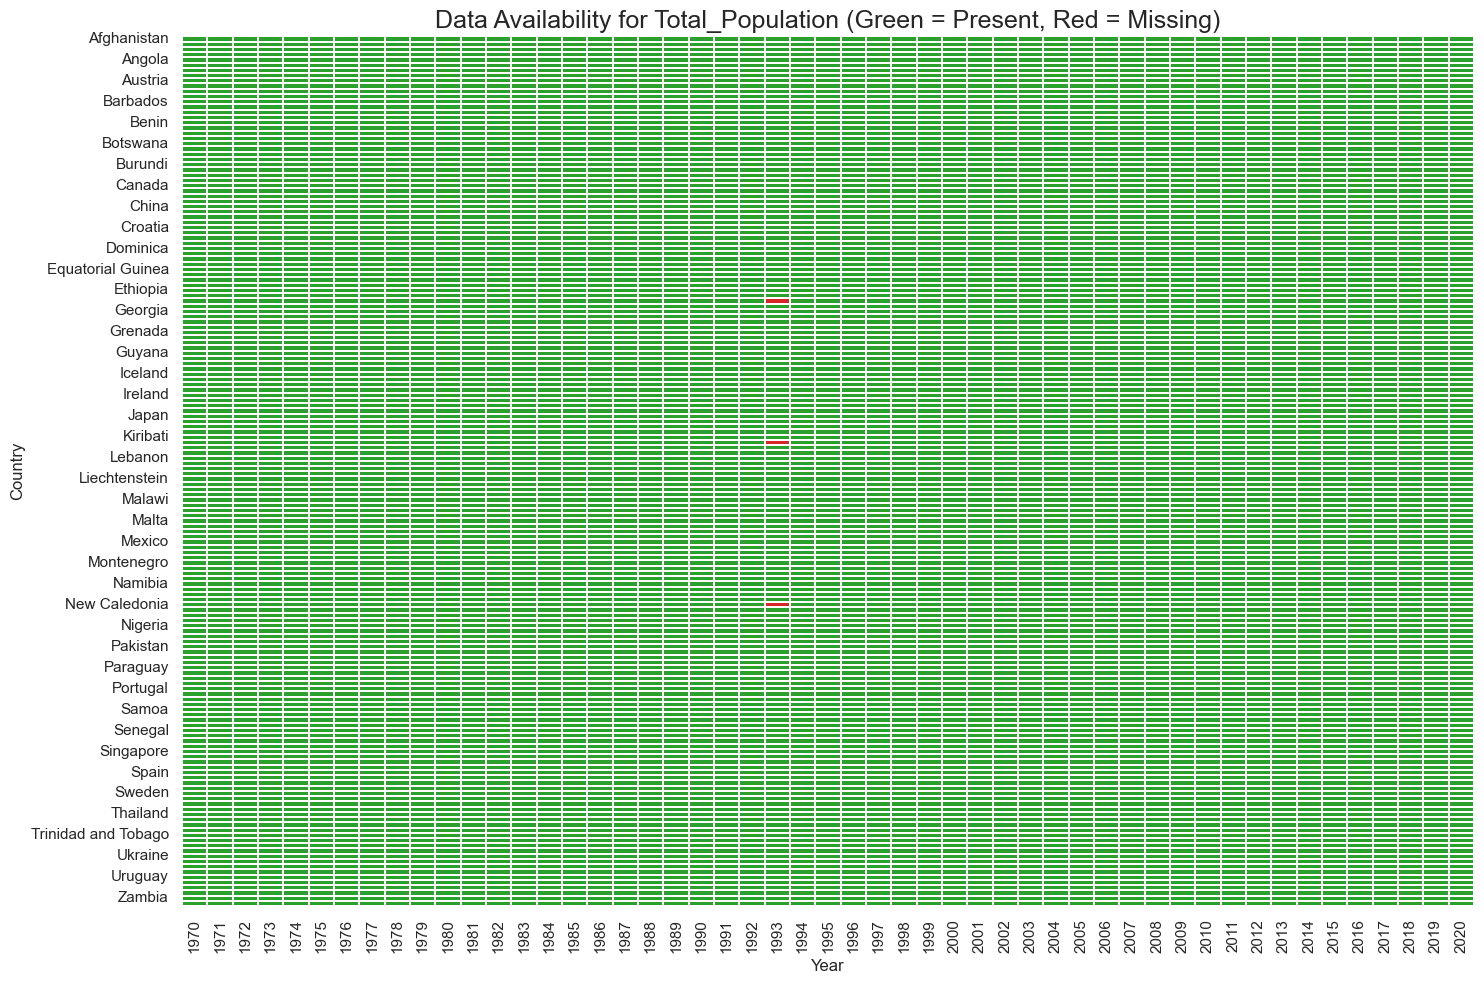

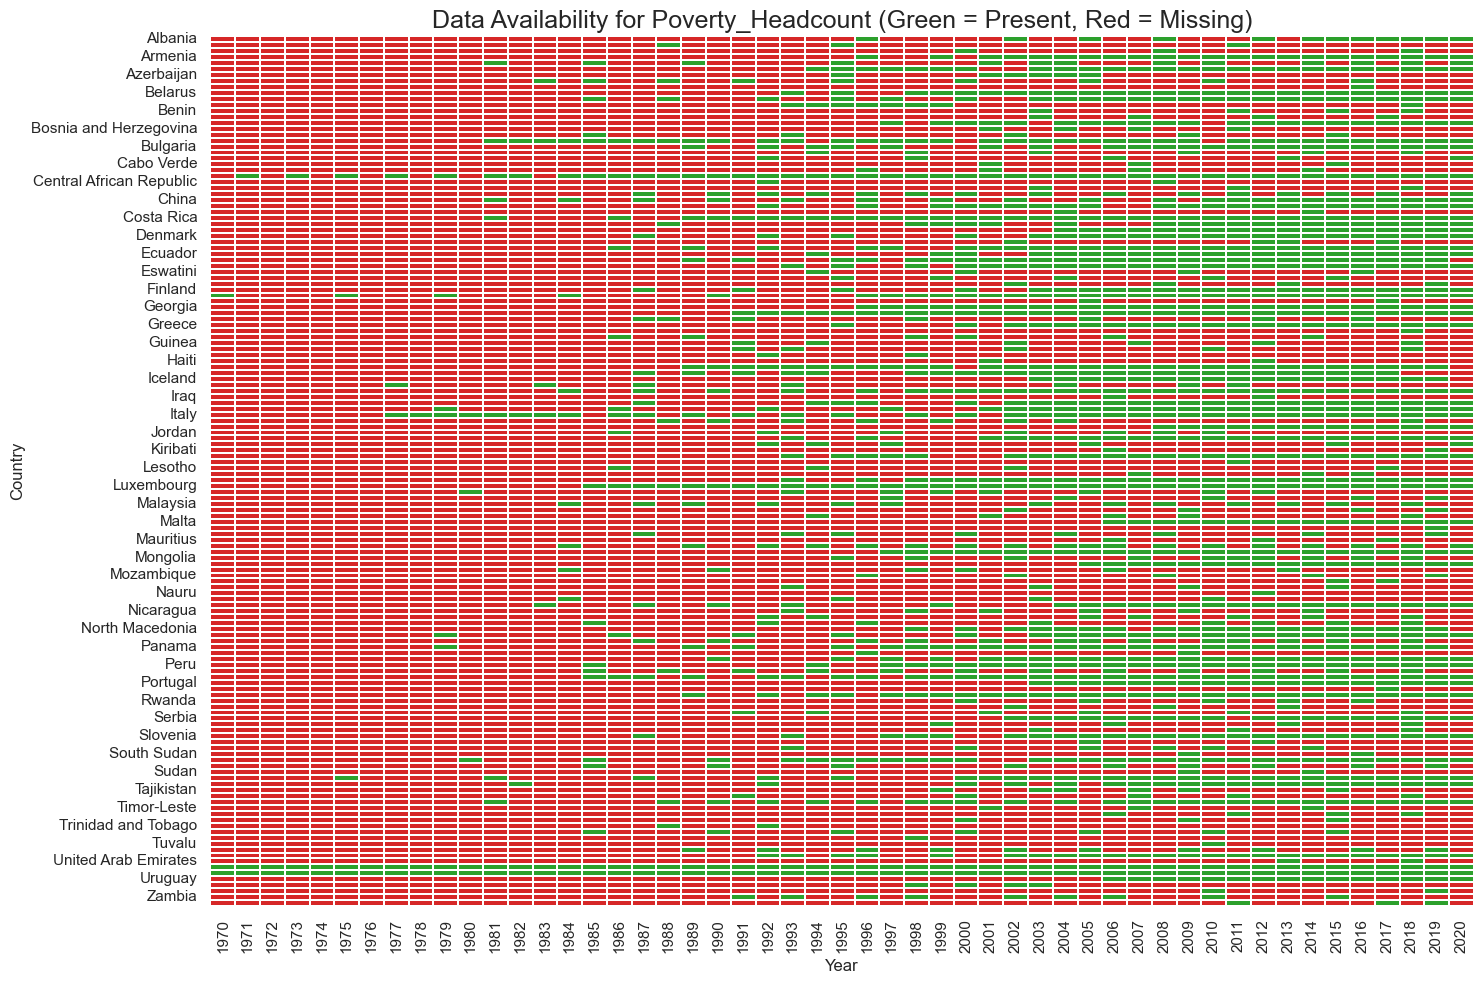

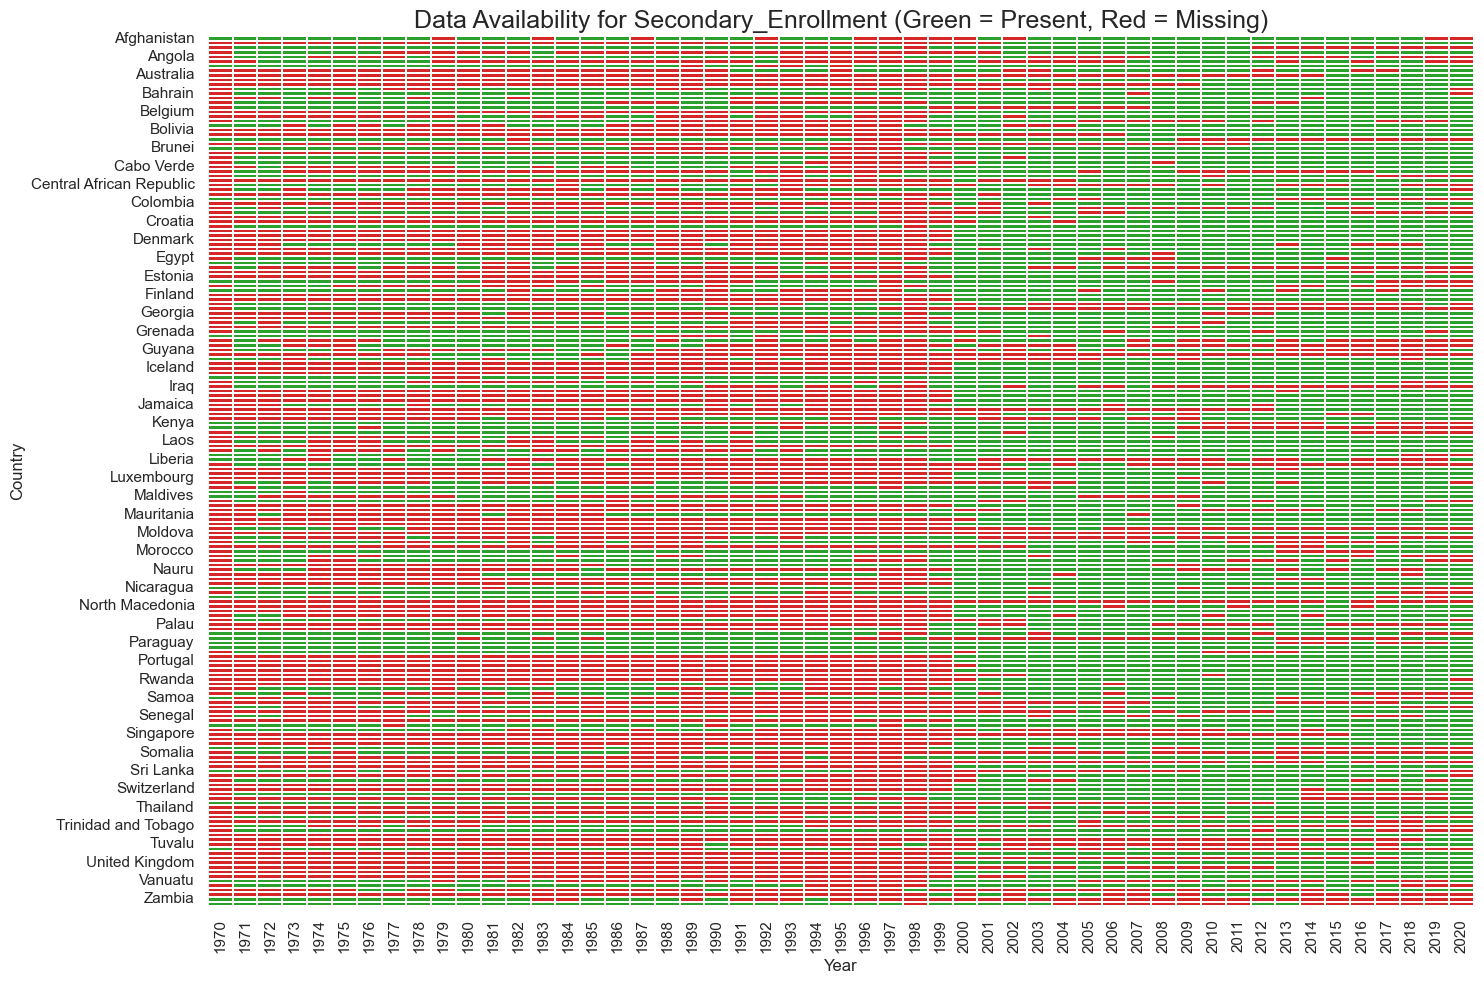

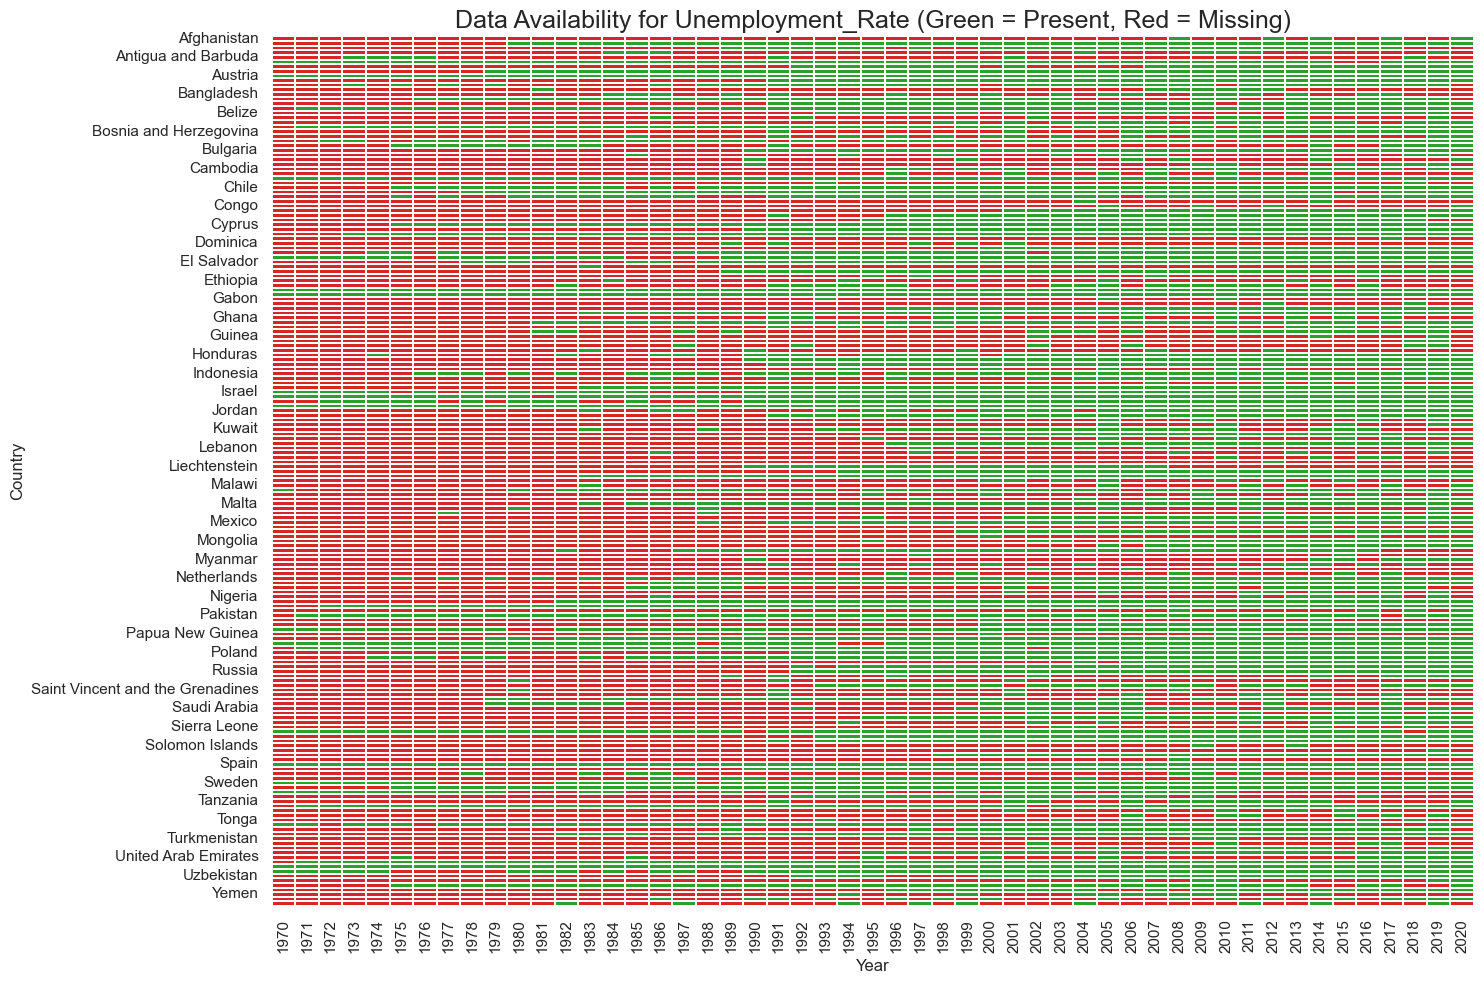

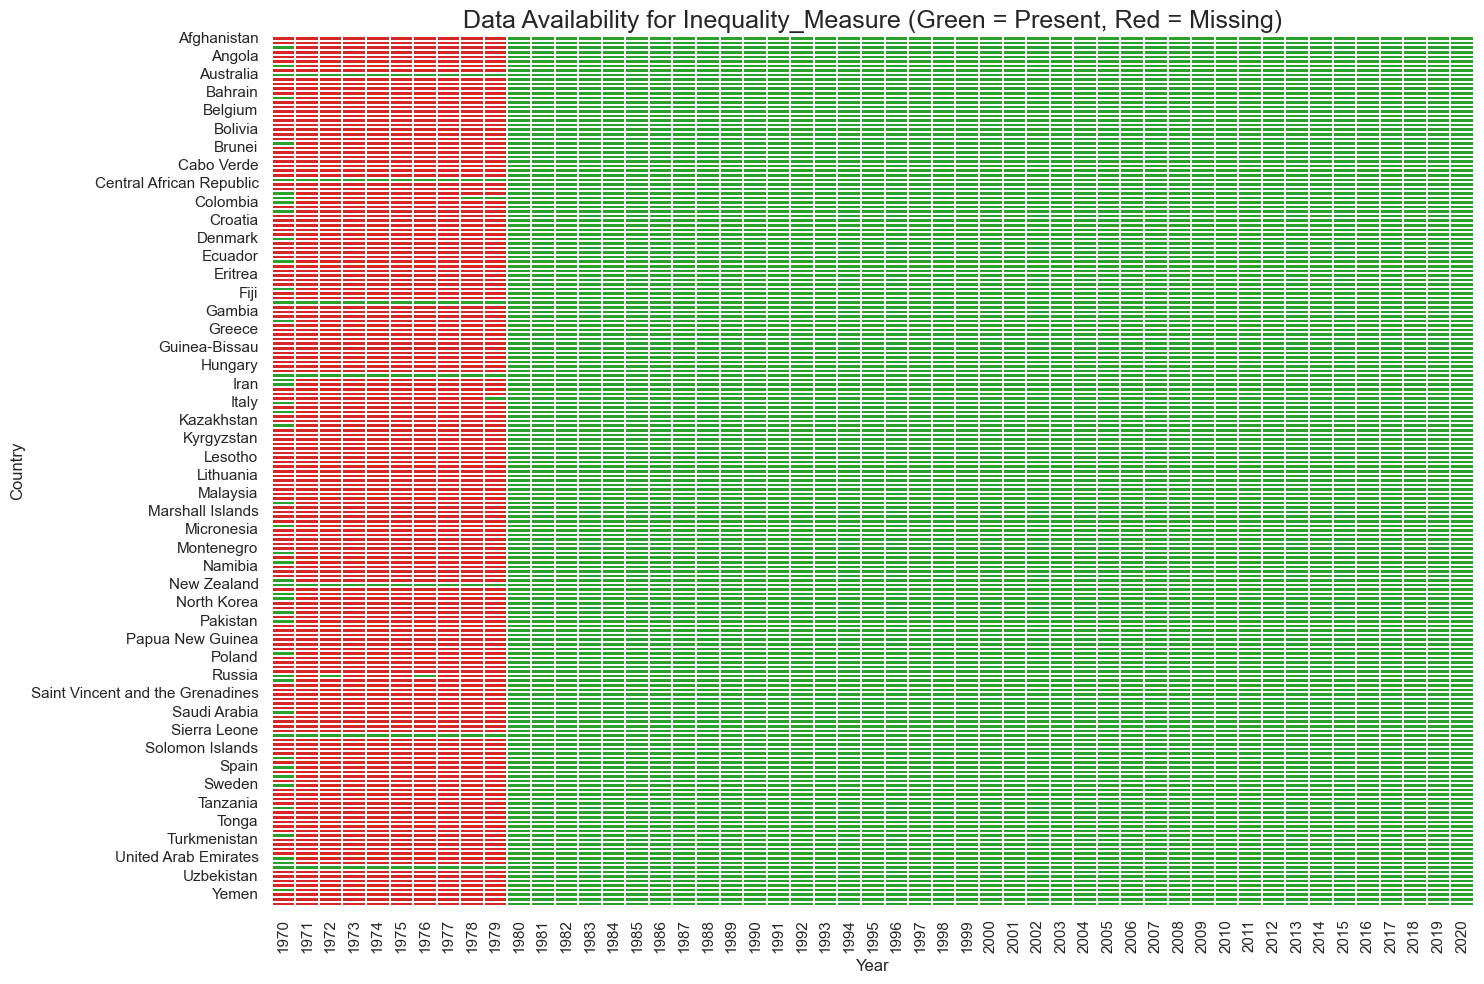

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\Final_Master_Panel_AllColumns.xlsx")
df.columns = df.columns.str.strip()

numeric_cols = [
    'GDP',
    'Total_Population',
    'Poverty_Headcount',
    'Secondary_Enrollment',
    'Unemployment_Rate',
    'Inequality_Measure'
]

# Convert to numeric
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

sns.set_theme(style="white")

for col in numeric_cols:
    # Pivot with aggregation to handle duplicates
    pivot_df = df.pivot_table(
        index="Country",
        columns="Year",
        values=col,
        aggfunc="mean"
    )

    # Binary mask: 1 = present, 0 = missing
    presence_mask = pivot_df.notna().astype(int)

    plt.figure(figsize=(15, 10))
    sns.heatmap(
        presence_mask,
        cmap=["#d62728", "#2ca02c"],  # red = missing, green = present
        cbar=False,
        linewidths=0.3
    )

    plt.title(f"Data Availability for {col} (Green = Present, Red = Missing)", fontsize=18)
    plt.xlabel("Year")
    plt.ylabel("Country")
    plt.tight_layout()
    plt.show()


Attacks vs GDP
Test used: Spearman Rank Correlation

Hypotheses
H₀: No monotonic association between GDP and attacks
H₁: A monotonic association exists

In [7]:
from scipy.stats import spearmanr

temp = df[['Attacks', 'GDP']].dropna()

rho, p = spearmanr(temp['Attacks'], temp['GDP'])

print(f"Spearman rho (Attacks vs GDP): {rho:.3f}, p-value: {p:.4f}")


Spearman rho (Attacks vs GDP): -0.027, p-value: 0.1051


Interpretation template
ρ < 0 → Higher GDP ↔ fewer attacks
p < 0.05 → Statistically significant association

Attacks vs Poverty Headcount
Test used: Spearman Rank Correlation

In [15]:
temp = df[['Attacks', 'Poverty_Headcount']].dropna()

rho, p = spearmanr(temp['Attacks'], temp['Poverty_Headcount'])

print(f"Spearman rho (Attacks vs Poverty): {rho:.3f}, p-value: {p:.4f}")


Spearman rho (Attacks vs Poverty): 0.034, p-value: 0.2738


Interpretation
ρ > 0 → Higher poverty ↔ more attacks

Attacks vs Secondary Enrollment

In [16]:
temp = df[['Attacks', 'Secondary_Enrollment']].dropna()

rho, p = spearmanr(temp['Attacks'], temp['Secondary_Enrollment'])

print(f"Spearman rho (Attacks vs Education): {rho:.3f}, p-value: {p:.4f}")


Spearman rho (Attacks vs Education): 0.015, p-value: 0.5147


Interpretation
ρ < 0 → Education associated with fewer attacks

Attacks vs Unemployment Rate

In [10]:
temp = df[['Attacks', 'Unemployment_Rate']].dropna()

rho, p = spearmanr(temp['Attacks'], temp['Unemployment_Rate'])

print(f"Spearman rho (Attacks vs Unemployment): {rho:.3f}, p-value: {p:.4f}")


Spearman rho (Attacks vs Unemployment): 0.065, p-value: 0.0021


Interpretation:
There is a very weak positive association between unemployment and terrorist attacks. Although the correlation coefficient is small, the relationship is statistically significant, indicating that higher unemployment levels are associated with a marginal increase in the number of attacks.

Attacks vs Inequality Measure

In [11]:
temp = df[['Attacks', 'Inequality_Measure']].dropna()

rho, p = spearmanr(temp['Attacks'], temp['Inequality_Measure'])

print(f"Spearman rho (Attacks vs Inequality): {rho:.3f}, p-value: {p:.4f}")


Spearman rho (Attacks vs Inequality): 0.089, p-value: 0.0000


Interpretation:
There is a weak but statistically significant positive association between inequality and terrorist attacks. Higher levels of inequality tend to be associated with a slight increase in the number of attacks.

STEP 1: Univariate Negative Binomial

(Attacks with ONE indicator at a time)

This replaces pairwise tests with model-based inference.

In [17]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Load data
df = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\Final_Master_Panel_AllColumns.xlsx")
df.columns = df.columns.str.strip()

indicators = [
    'GDP',
    'Poverty_Headcount',
    'Secondary_Enrollment',
    'Unemployment_Rate',
    'Inequality_Measure'
]

# Convert to numeric
for col in indicators + ['Attacks']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

nb_results = []

for var in indicators:
    temp = df[['Attacks', var]].dropna()

    X = sm.add_constant(temp[var])
    y = temp['Attacks']

    model = sm.GLM(
        y,
        X,
        family=sm.families.NegativeBinomial()
    ).fit()

    coef = model.params[var]
    pval = model.pvalues[var]
    irr = np.exp(coef)

    nb_results.append([var, coef, irr, pval])

nb_univariate = pd.DataFrame(
    nb_results,
    columns=['Indicator', 'Coefficient', 'IRR', 'p_value']
)

print(nb_univariate)


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dis

              Indicator  Coefficient        IRR       p_value
0                   GDP    -0.002213   0.997789  3.744003e-01
1     Poverty_Headcount     0.336129   1.399519  3.214600e-02
2  Secondary_Enrollment    -0.006725   0.993298  2.189123e-24
3     Unemployment_Rate    -0.002713   0.997291  5.154269e-01
4    Inequality_Measure     2.679093  14.571867  1.124766e-53


Interpretation

GDP: No statistically significant effect on terrorist attacks (IRR ≈ 1, p = 0.374). Changes in GDP alone do not meaningfully alter attack frequency.

Poverty Headcount: Statistically significant positive association (IRR = 1.40, p = 0.032). Higher poverty levels are associated with an increase in expected attacks.

Secondary Enrollment: Statistically significant negative association (IRR = 0.993, p < 0.001). Higher education levels correspond to a small reduction in attacks.

Unemployment Rate: No significant effect (IRR ≈ 0.997, p = 0.515). Unemployment alone does not predict attack frequency.

Inequality Measure: Strong, highly significant positive effect (IRR = 14.57, p < 0.001). Higher inequality is associated with a substantial increase in expected terrorist attacks and emerges as the most influential predictor among the indicators.

STEP 2: Multivariate Negative Binomial (Core Model)

Only include indicators that:
Are theoretically justified
Not completely insignificant above

In [18]:
vars_to_use = [
    'Poverty_Headcount',
    'Unemployment_Rate',
    'Inequality_Measure'
]

temp = df[['Attacks'] + vars_to_use].dropna()

X = sm.add_constant(temp[vars_to_use])
y = temp['Attacks']

nb_multi = sm.GLM(
    y,
    X,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_multi.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                Attacks   No. Observations:                  922
Model:                            GLM   Df Residuals:                      918
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4390.4
Date:                Wed, 28 Jan 2026   Deviance:                       2748.5
Time:                        09:24:19   Pearson chi2:                 6.66e+03
No. Iterations:                    12   Pseudo R-squ. (CS):             0.1243
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  3.1449      0

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


Interpretation

Poverty Headcount: Statistically significant positive effect (IRR = 1.80, p = 0.014). A one-unit increase in poverty increases the expected number of attacks by ~80%, holding other variables constant.

Unemployment Rate: Statistically significant negative effect (IRR = 0.96, p < 0.001). Surprisingly, higher unemployment is associated with a slight reduction in attacks when controlling for poverty and inequality. This may reflect complex socio-economic interactions.

Inequality Measure: Strong and highly significant positive effect (IRR = 8.70, p < 0.001). Higher inequality is associated with a substantial increase in expected attacks, confirming it as the dominant predictor in the multivariate model.

Intercept: Reflects the baseline expected attack level when all covariates are zero.

STEP 3: Panel Fixed Effects (Country FE)

This controls for time-invariant country characteristics.

In [21]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# -------------------------
# 1️⃣ Load and clean data
# -------------------------
df = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\Final_Master_Panel_AllColumns.xlsx")
df.columns = df.columns.str.strip()  # remove extra spaces

# Indicators to include
vars_to_use = ['Poverty_Headcount', 'Unemployment_Rate', 'Inequality_Measure']

# Ensure numeric
for col in vars_to_use + ['Attacks']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# -------------------------
# 2️⃣ Prepare X and y
# -------------------------
# Keep only needed columns
temp = df[['Country', 'Attacks'] + vars_to_use].dropna()

# Create country dummies for fixed effects
X = pd.get_dummies(temp[['Country'] + vars_to_use], drop_first=True)

# Dependent variable
y = temp['Attacks']

# Concatenate to drop any remaining NaNs (just in case)
data = pd.concat([y, X], axis=1).dropna()
y_clean = data['Attacks'].astype(float)
X_clean = data.drop(columns=['Attacks']).astype(float)

# Add constant term
X_clean = sm.add_constant(X_clean)

# -------------------------
# 3️⃣ Fit Negative Binomial GLM
# -------------------------
nb_fe = sm.GLM(
    y_clean,
    X_clean,
    family=sm.families.NegativeBinomial()
).fit(cov_type='HC3')  # robust SE


# -------------------------
# 4️⃣ Show summary
# -------------------------
print(nb_fe.summary())

# -------------------------
# 5️⃣ Optional: IRR table for interpretation
# -------------------------
irr = np.exp(nb_fe.params)
irr_df = pd.DataFrame({
    'IRR': irr,
    'p_value': nb_fe.pvalues
})

print("\n--- IRR Table ---")
print(irr_df)


c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:                Attacks   No. Observations:                  922
Model:                            GLM   Df Residuals:                      822
Model Family:        NegativeBinomial   Df Model:                           99
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3398.0
Date:                Wed, 28 Jan 2026   Deviance:                       763.59
Time:                        09:28:06   Pearson chi2:                     980.
No. Iterations:                    17   Pseudo R-squ. (CS):             0.8983
Covariance Type:                  HC3                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

How to interpret this output

Coefficients: Log-linear effect of each predictor (including fixed effects) on the expected number of attacks.

IRR (exp(coef)): Multiplicative change in expected attacks for a one-unit increase in a predictor.

HC3 robust SE: Corrects for potential heteroskedasticity due to many country dummies.

Intercept and country dummies: Control for baseline differences across countries.

STEP 4: IRR Table (PPT / Report-ready)

In [22]:
irr = np.exp(nb_fe.params)
irr_df = pd.DataFrame({
    'IRR': irr,
    'p_value': nb_fe.pvalues
})

print(irr_df)


                               IRR       p_value
const                    65.567565  8.029231e-14
Poverty_Headcount         0.587462  3.460703e-01
Unemployment_Rate         1.016320  2.143313e-01
Inequality_Measure        0.000031  3.336563e-15
Country_Algeria         110.057459  7.921623e-11
...                            ...           ...
Country_United Kingdom   42.244919  6.976265e-50
Country_United States    48.204527  1.100161e-47
Country_Uruguay           1.378774  2.027064e-01
Country_Zambia           18.588088  9.646776e-11
Country_Zimbabwe          8.343548  2.084588e-03

[100 rows x 2 columns]
